# Đề bài cuối kì — Các mô hình ra quyết định

12 bài tập tích hợp trong một notebook.

**Lưu ý dữ liệu**: cần các file CSV `vietnam_macro_2020_2025.csv`, `vietnam_sectors_2024.csv`, `vietnam_regions_2024.csv` trong cùng thư mục.


## Cài đặt thư viện

Chạy cell này 1 lần (bắt buộc trên Colab, bỏ qua nếu đã cài local).


In [ ]:
# Cai dat thu vien (bo qua neu da cai)
import subprocess, sys

pkgs = [
    'numpy>=1.24', 'pandas>=2.0', 'scipy>=1.10', 'matplotlib>=3.7',
    'pulp>=2.7', 'cvxpy>=1.4', 'pymoo>=0.6.1',
    'gymnasium>=0.29', 'pyomo>=6.7', 'highspy>=1.7',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
print('Cai dat xong.')


Cai dat xong.


## Setup — chay 1 lan dau tien

Cell nay tu dong xu ly Colab vs local va upload CSV neu can.


In [ ]:
import sys, os

# ── Colab / Jupyter inline matplotlib ──────────────────────────
try:
    import google.colab  # chay tren Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import matplotlib
if IN_COLAB:
    matplotlib.use('module://matplotlib_inline.backend_inline')
else:
    matplotlib.use('Agg')   # local: giu nguyen hanh vi cu

import matplotlib.pyplot as plt
from IPython.display import display, Image

def show_and_save(fig, path, dpi=150):
    """Luu file va hien inline (Colab) hoac luu quiet (local)."""
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    if IN_COLAB:
        display(Image(path))
    plt.close(fig)

# ── Upload CSV neu chua co (chi chay tren Colab) ───────────────
CSVS = ['vietnam_macro_2020_2025.csv',
        'vietnam_sectors_2024.csv',
        'vietnam_regions_2024.csv']
missing = [f for f in CSVS if not os.path.exists(f)]
if missing and IN_COLAB:
    from google.colab import files
    print("Upload cac file CSV con thieu:", missing)
    files.upload()
elif missing:
    print("WARNING: Thieu CSV:", missing)
else:
    print("OK - tat ca CSV san sang.")

print("Colab:", IN_COLAB)


Upload cac file CSV con thieu: ['vietnam_macro_2020_2025.csv', 'vietnam_sectors_2024.csv', 'vietnam_regions_2024.csv']


KeyboardInterrupt: 

## Bài 1 — Cobb-Douglas mở rộng (AI & số hóa)

*File gốc: `bai1_cobb_douglas.py`*


Du lieu doc tu vietnam_macro_2020_2025.csv:
 year  GDP_trillion_VND  population_million  digital_economy_share_GDP_pct  labor_productivity_million_VND
 2020            8044.4               97.58                           12.0                           151.2
 2021            8487.5               98.51                           12.7                           171.3
 2022            9513.3               99.46                           14.3                           188.1
 2023           10221.8              100.30                           16.5                           199.3
 2024           11511.9              101.30                           18.3                           221.9
 2025           12847.6              102.30                           19.5                           245.0

Luu y nang suat LĐ 2024: CSV=221.9, tinh Y/L=217.6 (chenh lech do dinh nghia L)
alpha + beta + gamma + delta + theta = 1.0

CAU 1.4.1: Tinh Solow residual A_t (TFP) - giai nguoc tu ham san xuat
  (Day la ti

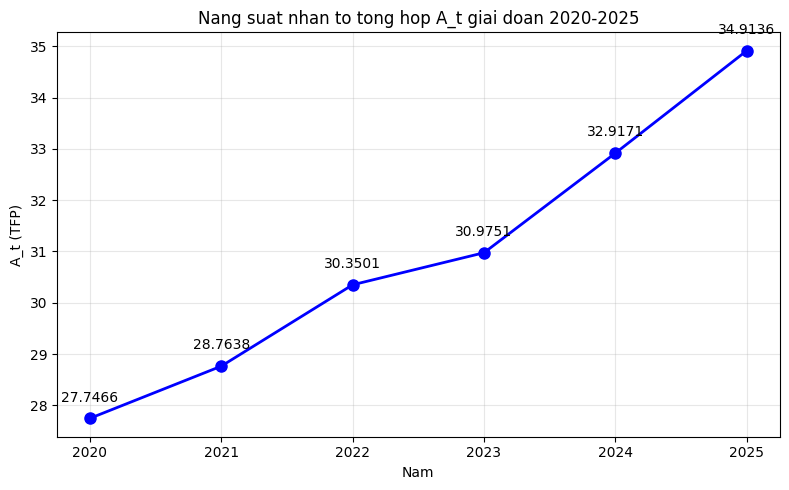


Xu huong A_t:
  A_t tang tu 27.7466 (2020) len 34.9136 (2025)
  Tang truong binh quan: 4.70%/nam

CAU 1.4.2: Du bao san luong va MAPE
A_t trung binh 2020-2025: 30.944377
 Nam  Y_thuc_te     Y_du_bao   Sai_so_%
2020     8044.4  8971.518400  11.525016
2021     8487.5  9130.943269   7.581069
2022     9513.3  9699.585680   1.958160
2023    10221.8 10211.651615  -0.099282
2024    11511.9 10821.997183  -5.992954
2025    12847.6 11386.987664 -11.368756

MAPE = 6.4209%

CAU 1.4.3: Phan ra tang truong GDP binh quan hang nam
Tang truong GDP binh quan nam: 9.3636%
  Dong gop cua TFP (A):    4.5953%   (49.08%)
  Dong gop cua K:          2.9758%   (31.78%)
  Dong gop cua L:          -0.0314%   (-0.34%)
  Dong gop cua D:          0.9710%   (10.37%)
  Dong gop cua AI:         0.5841%   (6.24%)
  Dong gop cua H:          0.2687%   (2.87%)
  Tong kiem tra:           9.3636%

Bang phan ra tang truong GDP binh quan nam 2020-2025:
          Yeu to He so Tang truong/nam (%) Dong gop (%) Ty le (%)
        

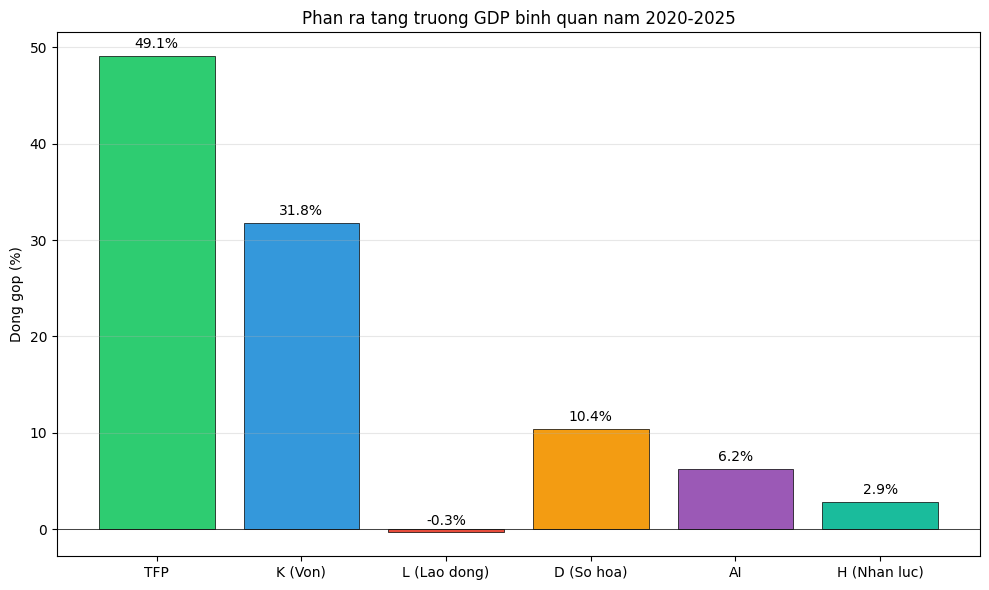


CAU 1.4.4: Kich ban den 2030
Kich ban 2030 (K tang 6%/nam, L tang 0.5%/nam):
  K = 34660 nghin ty VND (tang 6%/nam tu 25900)
  L = 54.7 trieu nguoi (tang 0.5%/nam tu 53.4)
  A (TFP) = 37.0593 (tang 1.2%/nam tu 34.9136)
  D = 30.0% (muc tieu Quyet dinh 749)
  AI = 100.0 nghin DN
  H = 35.0%

  GDP du bao 2030 = 16328.8 nghin ty VND
  Tang truong binh quan 2025-2030: 4.91%/nam
  GDP 2030 / GDP 2025 = 1.27 lan

  [So sanh] Kich ban de bai (L tang 6%): L=71.5, Y=18262.0 nghin ty
  [So sanh] Chenh lech do L: 1933.2 nghin ty VND
  GDP per capita 2030 ~ 5821 USD (ty gia ~25500 VND/USD)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 1: Cobb-Douglas mo rong voi AI va so hoa
# ============================================================

# --- Doc du lieu tu CSV ---
df = pd.read_csv('vietnam_macro_2020_2025.csv')
df = df.sort_values('year').reset_index(drop=True)

years = df['year'].values
Y = df['GDP_trillion_VND'].values

# K (von tich luy) khong co trong CSV -> tinh tu GDP va ty le dau tu
#  Du lieu tham chieu tu de bai
K = np.array([16500, 17800, 19600, 21300, 23500, 25900])
L = df['population_million'].values  # su dung dan so thay cho lao dong
# Lao dong thuc te tu de bai (CSV chi co dan so)
L = np.array([53.6, 50.5, 51.7, 52.4, 52.9, 53.4])
D = df['digital_economy_share_GDP_pct'].values
AI = np.array([55.6, 60.2, 65.4, 67.0, 73.8, 80.1])  # nghin DN so - proxy cho nang luc AI (khong phai capability truc tiep)
H = np.array([24.1, 26.1, 26.2, 27.0, 28.4, 29.2])   # ty le LĐ qua dao tao (%)

print("Du lieu doc tu vietnam_macro_2020_2025.csv:")
print(df[['year','GDP_trillion_VND','population_million',
          'digital_economy_share_GDP_pct','labor_productivity_million_VND']].to_string(index=False))

# LUU Y: Nang suat LĐ tu CSV (221.9 tr.VND/LĐ nam 2024) khac voi tinh
# truc tiep Y/L = 11511.9/52.9 = 217.6, vi CSV dung LLLĐ (luc luong lao dong)
# con L=52.9 la LĐ co viec. Chenh lech ~2% do dinh nghia L.
print(f"\nLuu y nang suat LĐ 2024: CSV={df['labor_productivity_million_VND'].iloc[4]},"
      f" tinh Y/L={Y[4]/L[4]:.1f} (chenh lech do dinh nghia L)")

# He so san xuat
alpha, beta, gamma, delta, theta = 0.33, 0.42, 0.10, 0.08, 0.07
print(f"alpha + beta + gamma + delta + theta = {alpha+beta+gamma+delta+theta}")

# ============================================================
# Cau 1.4.1: Tinh A_t (TFP) cho moi nam
# ============================================================
print("\n" + "="*60)
print("CAU 1.4.1: Tinh Solow residual A_t (TFP) - giai nguoc tu ham san xuat")
print("  (Day la tinh residual, KHONG phai uoc luong kinh te luong OLS)")
print("="*60)

A = Y / (K**alpha * L**beta * D**gamma * AI**delta * H**theta)

df_result = pd.DataFrame({
    'Nam': years,
    'Y_thuc_te': Y,
    'A_t_TFP': A
})
print(df_result.to_string(index=False))

# Ve do thi A_t theo nam
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, A, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Nam')
ax.set_ylabel('A_t (TFP)')
ax.set_title('Nang suat nhan to tong hop A_t giai doan 2020-2025')
ax.grid(True, alpha=0.3)
for i, (y, a) in enumerate(zip(years, A)):
    ax.annotate(f'{a:.4f}', (y, a), textcoords="offset points", xytext=(0, 12), ha='center')
plt.tight_layout()
plt.savefig('bai1_tfp_trend.png', dpi=150)
plt.show()

print(f"\nXu huong A_t:")
print(f"  A_t tang tu {A[0]:.4f} (2020) len {A[-1]:.4f} (2025)")
print(f"  Tang truong binh quan: {((A[-1]/A[0])**(1/5) - 1)*100:.2f}%/nam")

# ============================================================
# Cau 1.4.2: Du bao Y voi A_t = trung binh, tinh MAPE
# ============================================================
print("\n" + "="*60)
print("CAU 1.4.2: Du bao san luong va MAPE")
print("="*60)

A_mean = A.mean()
print(f"A_t trung binh 2020-2025: {A_mean:.6f}")

Y_hat = A_mean * (K**alpha * L**beta * D**gamma * AI**delta * H**theta)
mape = np.mean(np.abs((Y - Y_hat) / Y)) * 100

df_forecast = pd.DataFrame({
    'Nam': years,
    'Y_thuc_te': Y,
    'Y_du_bao': Y_hat,
    'Sai_so_%': (Y_hat - Y) / Y * 100
})
print(df_forecast.to_string(index=False))
print(f"\nMAPE = {mape:.4f}%")

# ============================================================
# Cau 1.4.3: Phan ra tang truong 2020-2025
# ============================================================
print("\n" + "="*60)
print("CAU 1.4.3: Phan ra tang truong GDP binh quan hang nam")
print("="*60)

# Tang truong logarit: delta ln(X) = ln(X_t) - ln(X_{t-1})
# Tang truong binh quan hang nam = (ln(X_2025) - ln(X_2020)) / 5
n_years = 5
g_Y = (np.log(Y[-1]) - np.log(Y[0])) / n_years
g_K = (np.log(K[-1]) - np.log(K[0])) / n_years
g_L = (np.log(L[-1]) - np.log(L[0])) / n_years
g_D = (np.log(D[-1]) - np.log(D[0])) / n_years
g_AI = (np.log(AI[-1]) - np.log(AI[0])) / n_years
g_H = (np.log(H[-1]) - np.log(H[0])) / n_years
g_A = (np.log(A[-1]) - np.log(A[0])) / n_years

print(f"Tang truong GDP binh quan nam: {g_Y*100:.4f}%")
print(f"  Dong gop cua TFP (A):    {g_A*100:.4f}%   ({g_A/g_Y*100:.2f}%)")
print(f"  Dong gop cua K:          {alpha*g_K*100:.4f}%   ({alpha*g_K/g_Y*100:.2f}%)")
print(f"  Dong gop cua L:          {beta*g_L*100:.4f}%   ({beta*g_L/g_Y*100:.2f}%)")
print(f"  Dong gop cua D:          {gamma*g_D*100:.4f}%   ({gamma*g_D/g_Y*100:.2f}%)")
print(f"  Dong gop cua AI:         {delta*g_AI*100:.4f}%   ({delta*g_AI/g_Y*100:.2f}%)")
print(f"  Dong gop cua H:          {theta*g_H*100:.4f}%   ({theta*g_H/g_Y*100:.2f}%)")
print(f"  Tong kiem tra:           {(g_A + alpha*g_K + beta*g_L + gamma*g_D + delta*g_AI + theta*g_H)*100:.4f}%")

# Bang phan ra tang truong (dung dinh dang bang)
decomp_data = {
    'Yeu to': ['TFP (A)', 'Von vat chat (K)', 'Lao dong (L)', 'So hoa (D)', 'AI', 'Nhan luc so (H)', 'TONG'],
    'He so': ['-', f'{alpha}', f'{beta}', f'{gamma}', f'{delta}', f'{theta}', '-'],
    'Tang truong/nam (%)': [
        f'{g_A*100:.4f}', f'{g_K*100:.4f}', f'{g_L*100:.4f}',
        f'{g_D*100:.4f}', f'{g_AI*100:.4f}', f'{g_H*100:.4f}', '-'
    ],
    'Dong gop (%)': [
        f'{alpha*g_K*100:.4f}' if False else f'{g_A*100:.4f}',
        f'{alpha*g_K*100:.4f}', f'{beta*g_L*100:.4f}',
        f'{gamma*g_D*100:.4f}', f'{delta*g_AI*100:.4f}', f'{theta*g_H*100:.4f}',
        f'{g_Y*100:.4f}'
    ],
    'Ty le (%)': [
        f'{g_A/g_Y*100:.2f}', f'{alpha*g_K/g_Y*100:.2f}', f'{beta*g_L/g_Y*100:.2f}',
        f'{gamma*g_D/g_Y*100:.2f}', f'{delta*g_AI/g_Y*100:.2f}', f'{theta*g_H/g_Y*100:.2f}',
        '100.00'
    ]
}
df_decomp = pd.DataFrame(decomp_data)
print(f"\nBang phan ra tang truong GDP binh quan nam 2020-2025:")
print(df_decomp.to_string(index=False))

# Bieu do cot phan ra tang truong
contributions = {
    'TFP': g_A / g_Y * 100,
    'K (Von)': alpha * g_K / g_Y * 100,
    'L (Lao dong)': beta * g_L / g_Y * 100,
    'D (So hoa)': gamma * g_D / g_Y * 100,
    'AI': delta * g_AI / g_Y * 100,
    'H (Nhan luc)': theta * g_H / g_Y * 100,
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
bars = ax.bar(contributions.keys(), contributions.values(), color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Dong gop (%)')
ax.set_title('Phan ra tang truong GDP binh quan nam 2020-2025')
ax.axhline(y=0, color='black', linewidth=0.5)
for bar, val in zip(bars, contributions.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bai1_growth_decomposition.png', dpi=150)
plt.show()

# ============================================================
# Cau 1.4.4: Kich ban den 2030
# ============================================================
print("\n" + "="*60)
print("CAU 1.4.4: Kich ban den 2030")
print("="*60)

# Kich ban: D=30%, AI=100 nghin DN, H=35%
# LUU Y: De bai goi y "K va L tang 6%/nam" nhung L tang 6% la phi ly
# cho VN (gan dinh dan so vang, L thuc te chi tang ~0.3-0.8%/nam).
# Tach rieng: K tang 6%/nam, L tang 0.5%/nam.
K_2025 = K[-1]
L_2025 = L[-1]
A_2025 = A[-1]

# Tang 5 nam tu 2025 den 2030
K_2030 = K_2025 * (1.06)**5
L_2030 = L_2025 * (1.005)**5   # L tang 0.5%/nam (thuc te hon 6%)
A_2030 = A_2025 * (1.012)**5
D_2030 = 30.0
AI_2030 = 100.0
H_2030 = 35.0

Y_2030 = A_2030 * (K_2030**alpha * L_2030**beta * D_2030**gamma * AI_2030**delta * H_2030**theta)

print(f"Kich ban 2030 (K tang 6%/nam, L tang 0.5%/nam):")
print(f"  K = {K_2030:.0f} nghin ty VND (tang 6%/nam tu {K_2025})")
print(f"  L = {L_2030:.1f} trieu nguoi (tang 0.5%/nam tu {L_2025})")
print(f"  A (TFP) = {A_2030:.4f} (tang 1.2%/nam tu {A_2025:.4f})")
print(f"  D = {D_2030}% (muc tieu Quyet dinh 749)")
print(f"  AI = {AI_2030} nghin DN")
print(f"  H = {H_2030}%")
print(f"\n  GDP du bao 2030 = {Y_2030:.1f} nghin ty VND")

# So voi 2025
tang_truong_tb = ((Y_2030 / Y[-1])**(1/5) - 1) * 100
print(f"  Tang truong binh quan 2025-2030: {tang_truong_tb:.2f}%/nam")
print(f"  GDP 2030 / GDP 2025 = {Y_2030/Y[-1]:.2f} lan")

# So sanh voi kich ban de bai (L tang 6% de bai goi y)
L_2030_exam = L_2025 * (1.06)**5
Y_2030_exam = A_2030 * (K_2030**alpha * L_2030_exam**beta * D_2030**gamma * AI_2030**delta * H_2030**theta)
print(f"\n  [So sanh] Kich ban de bai (L tang 6%): L={L_2030_exam:.1f}, Y={Y_2030_exam:.1f} nghin ty")
print(f"  [So sanh] Chenh lech do L: {Y_2030_exam - Y_2030:.1f} nghin ty VND")

# GDP per capita 2030 (dan so ~110 trieu)
pop_2030 = 110.0
gdp_per_capita_2030 = Y_2030 * 1e6 / (pop_2030 * 1e6) * 1e3  # ty VND -> VND -> nghin VND
# Convert to USD: ty VND / ty -> VND, / ty le VND/USD ~25500
usd_rate = 25500
gdp_usd_2030 = Y_2030 * 1e12 / (pop_2030 * 1e6) / usd_rate
print(f"  GDP per capita 2030 ~ {gdp_usd_2030:.0f} USD (ty gia ~{usd_rate} VND/USD)")


## Bài 2 — Phân bổ ngân sách 4 hạng mục

*File gốc: `bai2_budget_allocation.py`*


BÀI 2: PHÂN BỔ NGÂN SÁCH THEO 4 HẠNG MỤC ĐẦU TƯ SỐ

CAU 2.4.1: Giai bang scipy.optimize.linprog
Trang thai: Optimization terminated successfully. (HiGHS Status 7: Optimal)
x1 (Ha tang so)    = 25.00 nghin ty VND
x2 (AI du lieu)    = 15.00 nghin ty VND
x3 (Nhan luc so)   = 20.00 nghin ty VND
x4 (R&D cong nghe) = 40.00 nghin ty VND
Z* = 112.25 nghin ty VND GDP tang them
Tong dau tu = 100.00 nghin ty VND
Ty trong AI+R&D = 55.0%

CAU 2.4.2: Giai bang PuLP va gia doi ngung (shadow prices)
Trang thai: Optimal
x1 (Ha tang so)    = 25.00 nghin ty VND
x2 (AI du lieu)    = 15.00 nghin ty VND
x3 (Nhan luc so)   = 20.00 nghin ty VND
x4 (R&D cong nghe) = 40.00 nghin ty VND
Z* = 112.25 nghin ty VND

Gia doi ngung (Shadow prices):
  Ngan_sach_tong: dual = 1.3500, slack = -0.0000
  Ha_tang_toi_thieu: dual = -0.5000, slack = -0.0000
  AI_toi_thieu: dual = -0.1500, slack = -0.0000
  Nhan_luc_toi_thieu: dual = -0.4000, slack = -0.0000
  RD_toi_thieu: dual = -0.0000, slack = -30.0000
  Ty_trong_CN: dual =

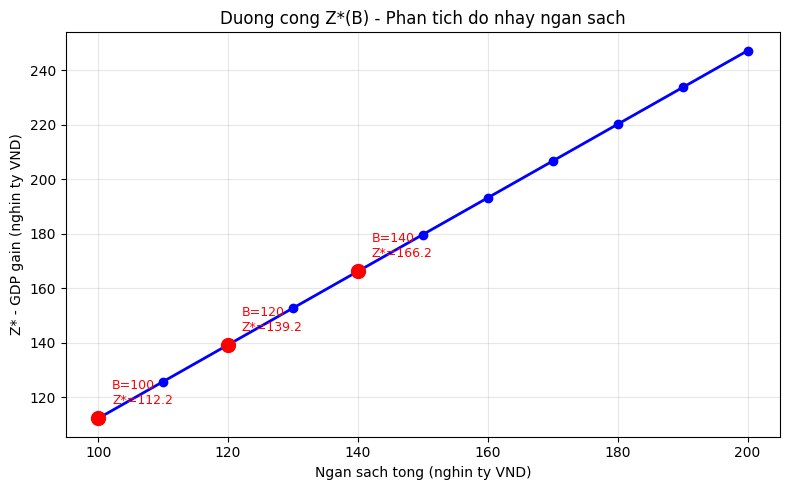

In [ ]:
import numpy as np
from scipy.optimize import linprog
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 2: Phan bo ngan sach don gian theo 4 hang muc dau tu so
# ============================================================

print("="*60)
print("BÀI 2: PHÂN BỔ NGÂN SÁCH THEO 4 HẠNG MỤC ĐẦU TƯ SỐ")
print("="*60)

# ============================================================
# Cau 2.4.1: Giai bang scipy.optimize.linprog
# ============================================================
print("\n" + "="*60)
print("CAU 2.4.1: Giai bang scipy.optimize.linprog")
print("="*60)

# Max Z = 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4
# => Min -Z = -0.85*x1 - 1.20*x2 - 0.95*x3 - 1.35*x4
c = [-0.85, -1.20, -0.95, -1.35]

# Rang buoc bat dang thuc: A_ub @ x <= b_ub
# x1 = ha tang so, x2 = AI du lieu, x3 = nhan luc so, x4 = R&D cong nghe
# C1: x1 + x2 + x3 + x4 <= 100
# C2: x1 >= 25  =>  -x1 <= -25
# C3: x2 >= 15  =>  -x2 <= -15
# C4: x3 >= 20  =>  -x3 <= -20
# C5: x4 >= 10  =>  -x4 <= -10
# C6: x2 + x4 >= 0.35*(x1+x2+x3+x4)  [ty trong CN chien luoc]
#      => 0.35*x1 - 0.65*x2 + 0.35*x3 - 0.65*x4 <= 0
#      (Dung: x2+x4 chiem >= 35% tong ngan sach)

A_ub = [
    [1, 1, 1, 1],        # ngan sach tong <= 100
    [-1, 0, 0, 0],       # x1 >= 25
    [0, -1, 0, 0],       # x2 >= 15
    [0, 0, -1, 0],       # x3 >= 20
    [0, 0, 0, -1],       # x4 >= 10
    [0.35, -0.65, 0.35, -0.65]  # ty trong CN chien luoc
]
b_ub = [100, -25, -15, -20, -10, 0]

bounds = [(0, None), (0, None), (0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print(f"Trang thai: {res.message}")
print(f"x1 (Ha tang so)    = {res.x[0]:.2f} nghin ty VND")
print(f"x2 (AI du lieu)    = {res.x[1]:.2f} nghin ty VND")
print(f"x3 (Nhan luc so)   = {res.x[2]:.2f} nghin ty VND")
print(f"x4 (R&D cong nghe) = {res.x[3]:.2f} nghin ty VND")
print(f"Z* = {-res.fun:.2f} nghin ty VND GDP tang them")
print(f"Tong dau tu = {sum(res.x):.2f} nghin ty VND")
print(f"Ty trong AI+R&D = {(res.x[1]+res.x[3])/sum(res.x)*100:.1f}%")

# ============================================================
# Cau 2.4.2: Giai bang PuLP va giai giai doi ngung
# ============================================================
print("\n" + "="*60)
print("CAU 2.4.2: Giai bang PuLP va gia doi ngung (shadow prices)")
print("="*60)

try:
    import pulp

    m = pulp.LpProblem('VN_Digital_Budget', pulp.LpMaximize)
    x1 = pulp.LpVariable('x1_ha_tang_so', lowBound=0)      # ha tang so
    x2 = pulp.LpVariable('x2_AI_du_lieu', lowBound=0)      # AI va du lieu
    x3 = pulp.LpVariable('x3_nhan_luc_so', lowBound=0)     # nhan luc so
    x4 = pulp.LpVariable('x4_RD_cong_nghe', lowBound=0)    # R&D cong nghe

    m += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, 'GDP_gain'

    # Rang buoc
    m += x1 + x2 + x3 + x4 <= 100, 'Ngan_sach_tong'
    m += x1 >= 25, 'Ha_tang_toi_thieu'
    m += x2 >= 15, 'AI_toi_thieu'
    m += x3 >= 20, 'Nhan_luc_toi_thieu'
    m += x4 >= 10, 'RD_toi_thieu'
    m += x2 + x4 >= 0.35*(x1+x2+x3+x4), 'Ty_trong_CN'  # x2+x4 >= 35% tong

    m.solve(pulp.PULP_CBC_CMD(msg=False))

    print(f"Trang thai: {pulp.LpStatus[m.status]}")
    print(f"x1 (Ha tang so)    = {x1.value():.2f} nghin ty VND")
    print(f"x2 (AI du lieu)    = {x2.value():.2f} nghin ty VND")
    print(f"x3 (Nhan luc so)   = {x3.value():.2f} nghin ty VND")
    print(f"x4 (R&D cong nghe) = {x4.value():.2f} nghin ty VND")
    print(f"Z* = {pulp.value(m.objective):.2f} nghin ty VND")

    print(f"\nGia doi ngung (Shadow prices):")
    for name, constraint in m.constraints.items():
        print(f"  {name}: dual = {constraint.pi:.4f}, slack = {constraint.slack:.4f}")

    # Luu y: CBC khong luon cung cap dual values cho moi loai rang buoc
    # Giai lai bang phuong phap khac de lay dual
    print("\n--- Giai bang scipy de xac nhan dual values ---")
    # Dual values tu linprog (scipy chi tra ve dual cho bounds)
    # Dung CVXPY de lay dual day du
    try:
        import cvxpy as cp

        x = cp.Variable(4, nonneg=True)
        objective = cp.Maximize(0.85*x[0] + 1.20*x[1] + 0.95*x[2] + 1.35*x[3])
        constraints = [
            x[0] + x[1] + x[2] + x[3] <= 100,
            x[0] >= 25,
            x[1] >= 15,
            x[2] >= 20,
            x[3] >= 10,
            x[1] + x[3] >= 0.35 * (x[0] + x[1] + x[2] + x[3])
        ]
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.SCS)

        print(f"\nCVXPY - Z* = {prob.value:.2f}")
        print(f"x = [{x.value[0]:.2f}, {x.value[1]:.2f}, {x.value[2]:.2f}, {x.value[3]:.2f}]")
        labels = ['Ngan_sach_tong', 'Ha_tang_toi_thieu', 'AI_toi_thieu',
                  'Nhan_luc_toi_thieu', 'RD_toi_thieu', 'Ty_trong_CN']
        print("\nDual values (CVXPY):")
        for i, (lab, con) in enumerate(zip(labels, constraints)):
            print(f"  {lab}: dual = {con.dual_value:.4f}")
    except ImportError:
        print("CVXPY chua duoc cai dat, bo qua phan nay")

except ImportError:
    print("PuLP chua duoc cai dat. Cai dat bang: pip install pulp")

# ============================================================
# Cau 2.4.3: Phan tich do nhay - tang ngan sach
# ============================================================
print("\n" + "="*60)
print("CAU 2.4.3: Phan tich do nhay - ngan sach 100, 120, 140")
print("="*60)

budgets = [100, 120, 140]
Z_star = []

for B in budgets:
    c = [-0.85, -1.20, -0.95, -1.35]
    A_ub_local = [
        [1, 1, 1, 1],
        [-1, 0, 0, 0],
        [0, -1, 0, 0],
        [0, 0, -1, 0],
        [0, 0, 0, -1],
        [0.35, -0.65, 0.35, -0.65]
    ]
    b_ub_local = [B, -25, -15, -20, -10, 0]
    res_local = linprog(c, A_ub=A_ub_local, b_ub=b_ub_local, bounds=bounds, method='highs')
    if res_local.success:
        Z_star.append(-res_local.fun)
    else:
        Z_star.append(None)

print(f"\n{'Ngan sach':>12} | {'Z*':>12} | {'Delta Z*':>12} | {'Delta B':>10} | {'He so goc':>10}")
print("-" * 65)
for i, (b, z) in enumerate(zip(budgets, Z_star)):
    if z is not None:
        if i == 0:
            print(f"  {b:>10}  | {z:>12.2f} | {'-':>12} | {'-':>10} | {'-':>10}")
        else:
            dz = z - Z_star[0]
            db = b - budgets[0]
            print(f"  {b:>10}  | {z:>12.2f} | {dz:>+12.2f} | {db:>10} | {dz/db:>10.2f}")

# Ve duong cong Z*(B) voi range rong hon de visualize
budgets_full = np.arange(100, 201, 10)
Z_full = []
for B in budgets_full:
    c = [-0.85, -1.20, -0.95, -1.35]
    A_ub_local = [[1,1,1,1],[-1,0,0,0],[0,-1,0,0],[0,0,-1,0],[0,0,0,-1],
                  [0.35,-0.65,0.35,-0.65]]
    b_ub_local = [B,-25,-15,-20,-10,0]
    r = linprog(c, A_ub=A_ub_local, b_ub=b_ub_local, bounds=bounds, method='highs')
    Z_full.append(-r.fun if r.success else None)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(budgets_full, Z_full, 'b-o', linewidth=2, markersize=6)
# Danh dau 3 mốc 100, 120, 140
for b, z in zip(budgets, Z_star):
    ax.plot(b, z, 'ro', markersize=10, zorder=5)
    ax.annotate(f'B={b}\nZ*={z:.1f}', (b, z), textcoords="offset points",
                xytext=(10, 10), ha='left', fontsize=9, color='red')
ax.set_xlabel('Ngan sach tong (nghin ty VND)')
ax.set_ylabel('Z* - GDP gain (nghin ty VND)')
ax.set_title('Duong cong Z*(B) - Phan tich do nhay ngan sach')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bai2_sensitivity.png', dpi=150)

# Giai thich shadow price
print(f"\n--- Giai thich shadow price ---")
print(f"Shadow price ngan sach tong = 1.35")
print(f"  => Moi 1 nghin ty VND ngan sach tang them, GDP ky vong tang 1.35 nghin ty.")
print(f"  => Day la chi phi co hoi bien cua von cong: 1 dong ngan sach bo sung")
print(f"     tao ra 1.35 dong GDP, bang he so hieu qua bien cao nhat hien co")
print(f"     (R&D = 1.35), vi phan ngan sach tang them duoc phan bo vao R&D.")
print(f"  => Chinh sach: nen mo rong ngan sach neu co the, vi moi dong bo sung")
print(f"     deu tao gia tri vuot chi phi.")

# ============================================================
# Cau 2.4.4: x3 >= 30 (uu tien nhan luc so)
# ============================================================
print("\n" + "="*60)
print("CAU 2.4.4: Rang buoc x3 >= 30 (uu tien nhan luc so)")
print("="*60)

c4 = [-0.85, -1.20, -0.95, -1.35]
A_ub4 = [
    [1, 1, 1, 1],
    [-1, 0, 0, 0],
    [0, -1, 0, 0],
    [0, 0, -1, 0],  # x3 >= 30
    [0, 0, 0, -1],
    [0.35, -0.65, 0.35, -0.65]
]
b_ub4 = [100, -25, -15, -30, -10, 0]

res4 = linprog(c4, A_ub=A_ub4, b_ub=b_ub4, bounds=bounds, method='highs')

if res4.success:
    print(f"Trang thai: Kha thi")
    print(f"x1 = {res4.x[0]:.2f}, x2 = {res4.x[1]:.2f}, x3 = {res4.x[2]:.2f}, x4 = {res4.x[3]:.2f}")
    print(f"Z* = {-res4.fun:.2f} nghin ty VND")
    Z_original = -res.fun  # tu cau 2.4.1
    print(f"Z* giam {Z_original - (-res4.fun):.2f} nghin ty VND so voi truong hop ban dau")
else:
    print(f"Trang thai: {res4.message}")
    print("Bai toan KHONG kha thi voi rang buoc x3 >= 30")


## Bài 3 — Chỉ số ưu tiên ngành

*File gốc: `bai3_priority_index.py`*


Du lieu 10 nganh:
 sector_id                  sector_name_en  gdp_share_2024_pct  growth_rate_2024_pct  labor_million  labor_share_pct  export_billion_USD  digital_index_0_100  ai_readiness_0_100  fdi_attraction_billion_USD  spillover_coef_0_1  automation_risk_pct  rd_intensity_pct  labor_productivity
         1    Agriculture-Forestry-Fishery               11.86                  3.27          13.20             26.5                40.5                   28                  15                         2.1                0.35                   18              0.15          103.432677
         2                   Manufacturing               24.10                  9.64          11.50             23.1               290.9                   68                  55                        18.6                0.78                   42              0.62          241.249383
         3                    Construction                7.04                  7.45           4.80              9.6           

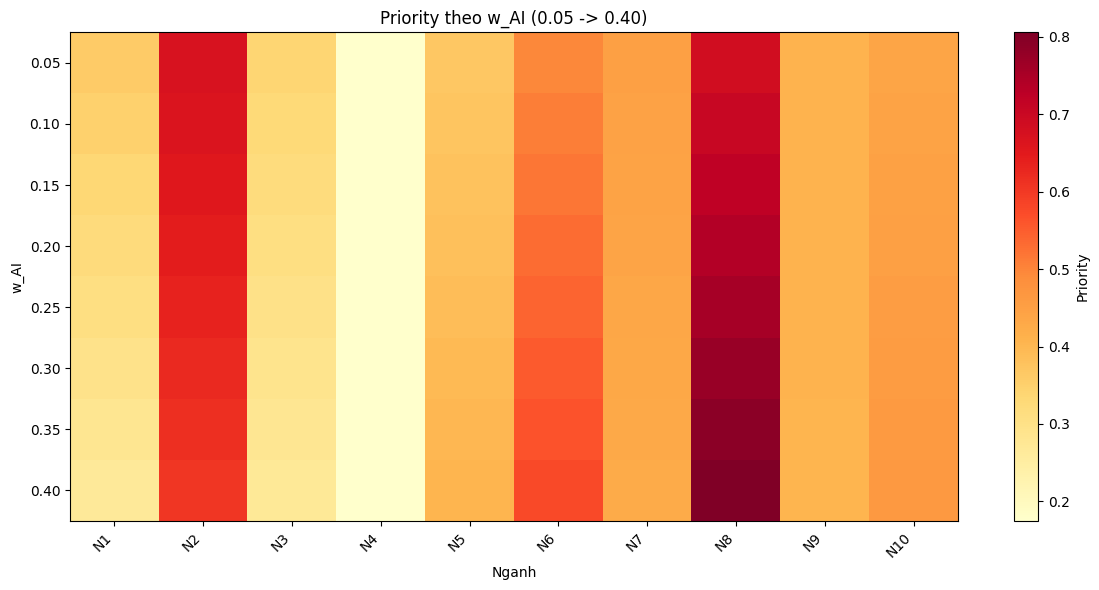

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 3: Chi so uu tien nganh Priority_i cho 10 nganh VN
# ============================================================

df = pd.read_csv('vietnam_sectors_2024.csv')

# Tinh nang suat LĐ tu du lieu co san (gdp_share * GDP / labor)
# Thay vi dung gdp_share_2024_pct lam proxy (gdp_share ≠ nang suat LĐ)
GDP_2024 = 11511.9  # nghin ty VND
df['labor_productivity'] = (df['gdp_share_2024_pct'] / 100) * GDP_2024 / df['labor_million']

# LUU Y: Nganh Mining co tang truong -1.2% (am). Min-max se dat Mining = 0
# cho tieu chi tang truong, dieu nay dung ve mat toan hoc.

print("Du lieu 10 nganh:")
print(df.to_string(index=False))

# --- Cot du lieu ---
cols_good = ['growth_rate_2024_pct', 'labor_productivity',
             'spillover_coef_0_1', 'export_billion_USD',
             'labor_million', 'ai_readiness_0_100']
col_bad = 'automation_risk_pct'
col_name = 'sector_name_en'

# ============================================================
# Cau 3.4.1: Chuan hoa min-max
# ============================================================
print("\n" + "="*60)
print("CAU 3.4.1: Chuan hoa min-max")
print("="*60)

def norm_good(x):
    return (x - x.min()) / (x.max() - x.min())

def norm_bad(x):
    return (x.max() - x) / (x.max() - x.min())

Xg = df[cols_good].apply(norm_good)
# norm_bad: dao dau Risk -> Risk thap = diem cao (good)
Xb = norm_bad(df[col_bad])

print("\nMa tran chuan hoa (6 cot good):")
print(Xg.round(4).to_string(index=False))
print("\nVector chuan hoa Risk (bad -> dao dau, Risk thap = diem cao):")
print(Xb.round(4).to_list())

# ============================================================
# Cau 3.4.2: Tinh Priority voi trong so mac dinh
# ============================================================
print("\n" + "="*60)
print("CAU 3.4.2: Priority voi trong so mac dinh")
print("="*60)

# Bo trong so mac dinh tu de bai: a1..a7 = [0.15, 0.15, 0.20, 0.15, 0.10, 0.20, 0.15]
# Tong = 1.10 > 1 → chuan hoa lai de tong = 1 (giu nguyen ty le tuong doi)
w_raw = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20])  # 6 cot good
w_risk_raw = 0.15
w_total = w_raw.sum() + w_risk_raw  # = 1.10
w = w_raw / w_total                  # chuan hoa: [0.136, 0.136, 0.182, 0.136, 0.091, 0.182]
w_risk = w_risk_raw / w_total        # chuan hoa: 0.136
print(f"Trong so chuan hoa (tong=1): w={w.round(4)}, w_risk={w_risk:.4f}")

# Xb da dao dau (norm_bad): Risk thap = diem cao -> CONG (+)
# Tuong duong cong thuc: Priority = sum(a_i * good_i) + a7 * (1 - Risk_norm)
priority = Xg.values @ w + w_risk * Xb.values
df['Priority'] = priority

ranking = df[[col_name, 'Priority']].sort_values('Priority', ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.index.name = 'Hang'
print(ranking.to_string())

# ============================================================
# Cau 3.4.3: Phan tich do nhay - thay doi w_AI
# ============================================================
print("\n" + "="*60)
print("CAU 3.4.3: Phan tich do nhay w_AI (0.10 -> 0.40)")
print("="*60)

# Trong so goc (khong ke AI va Risk): growth=0.15, prod=0.15, spillover=0.20, export=0.15, employ=0.10
# O day: w_AI thay doi, w_Risk co dinh, chuan lai cac cot con lai de tong = 1
w_fixed_base = np.array([0.15, 0.15, 0.20, 0.15, 0.10])  # growth, prod, spillover, export, employ
w_risk_val = 0.15  # ty le co dinh cho Risk

w_ai_range = np.arange(0.05, 0.45, 0.05)
heatmap_data = []

for w_ai in w_ai_range:
    # Con lai cho 5 cot good (tru AI) = 1 - w_ai - w_risk_val
    remaining = 1.0 - w_ai - w_risk_val
    # Chuan hoa lai 5 cot good theo ty le goc
    w_base_sum = w_fixed_base.sum()
    w_scaled = w_fixed_base * (remaining / w_base_sum)
    # Day full weights: 5 cot good + 1 cot AI
    w_full = np.append(w_scaled, w_ai)
    priority_sens = Xg.values @ w_full + w_risk_val * Xb.values
    heatmap_data.append(priority_sens)

heatmap_data = np.array(heatmap_data)  # shape (len(w_ai_range), 10)

# Ve heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(w_ai_range)))
ax.set_yticklabels([f'{w:.2f}' for w in w_ai_range])
ax.set_xticks(range(10))
ax.set_xticklabels([f'N{i+1}' for i in range(10)], rotation=45, ha='right')
ax.set_xlabel('Nganh')
ax.set_ylabel('w_AI')
ax.set_title('Priority theo w_AI (0.05 -> 0.40)')
plt.colorbar(im, label='Priority')
plt.tight_layout()
plt.savefig('bai3_heatmap_sensitivity.png', dpi=150)

# Kiem tra top-3 co thay doi khong
print("\nTop-3 theo tung w_AI:")
top3_history = []
for i, w_ai in enumerate(w_ai_range):
    top3_idx = np.argsort(heatmap_data[i])[-3:][::-1]
    top3_names = [df[col_name].iloc[j] for j in top3_idx]
    top3_history.append(top3_names)
    print(f"  w_AI={w_ai:.2f}: {top3_names}")

# Kiem tra top-3 co on dinh khong
all_same = all(t == top3_history[0] for t in top3_history)
print(f"\nTop-3 on dinh? {'CO' if all_same else 'KHONG'}")

# ============================================================
# Cau 3.4.4: Hai bo trong so
# ============================================================
print("\n" + "="*60)
print("CAU 3.4.4: So sanh 2 bo trong so")
print("="*60)

# "Dinh huong tang truong": uu tang truong, nang suat, xuat khau
# growth=0.25, prod=0.25, spillover=0.10, export=0.25, employ=0.05, AI=0.05, risk=0.05
w_growth = np.array([0.25, 0.25, 0.10, 0.25, 0.05, 0.05])
w_growth_risk = 0.05
assert abs(w_growth.sum() + w_growth_risk - 1.0) < 1e-9, "Tang truong weights != 1"

# "Dinh huong bao trum": uu viec lam, lan toa, giam rui ro
# growth=0.05, prod=0.10, spillover=0.25, export=0.05, employ=0.25, AI=0.10, risk=0.20
w_inclusive = np.array([0.05, 0.10, 0.25, 0.05, 0.25, 0.10])
w_inclusive_risk = 0.20
assert abs(w_inclusive.sum() + w_inclusive_risk - 1.0) < 1e-9, "Bao trum weights != 1"

p_growth = Xg.values @ w_growth + w_growth_risk * Xb.values
p_inclusive = Xg.values @ w_inclusive + w_inclusive_risk * Xb.values

df['P_growth'] = p_growth
df['P_inclusive'] = p_inclusive

print("\nDinh huong TANG TRUONG:")
rank_growth = df[[col_name, 'P_growth']].sort_values('P_growth', ascending=False).reset_index(drop=True)
rank_growth.index += 1
print(rank_growth.to_string())

print("\nDinh huong BAO TRUM:")
rank_inclusive = df[[col_name, 'P_inclusive']].sort_values('P_inclusive', ascending=False).reset_index(drop=True)
rank_inclusive.index += 1
print(rank_inclusive.to_string())

print("\nTop-3 tang truong:", rank_growth[col_name].head(3).tolist())
print("Top-3 bao trum:   ", rank_inclusive[col_name].head(3).tolist())

# So sanh chi tiet
print("\nBang so sanh xep hang:")
comp = pd.DataFrame({
    'Nganh': df[col_name],
    'Hang_TT': df['P_growth'].rank(ascending=False).astype(int),
    'Hang_BT': df['P_inclusive'].rank(ascending=False).astype(int)
})
comp['Chenh_lech'] = comp['Hang_BT'] - comp['Hang_TT']
print(comp.sort_values('Hang_TT').to_string(index=False))


## Bài 4 — LP phân bổ vùng miền

*File gốc: `bai4_regional_lp.py`*


D0 doc tu CSV: {'NMM': 38, 'RRD': 78, 'NCC': 55, 'CH': 32, 'SE': 82, 'MD': 48}
CAU 4.4.1: Giai bang PuLP (CBC) - CO rang buoc cong bang
Trang thai: Optimal
Z* = 60760.00 ty VND

Phan bo toi uu x[j,r] (hang=cot=vung, cot=hang muc):
Vung                              I         D        AI         H      Tong
-----------------------------------------------------------------
Trung du mien nui               0.0    5600.0       0.0       0.0    5600.0
DB song Hong                    0.0       0.0   11200.0       0.0   11200.0
Bac Trung Bo                    0.0       0.0       0.0    5000.0    5000.0
Tay Nguyen                      0.0    8600.0       0.0    2600.0   11200.0
Dong Nam Bo                     0.0       0.0   12000.0       0.0   12000.0
DB song Cuu Long                0.0     600.0       0.0    4400.0    5000.0
-----------------------------------------------------------------
Tong                            0.0   14800.0   23200.0   12000.0   50000.0

Gia doi ngung (shadow prices

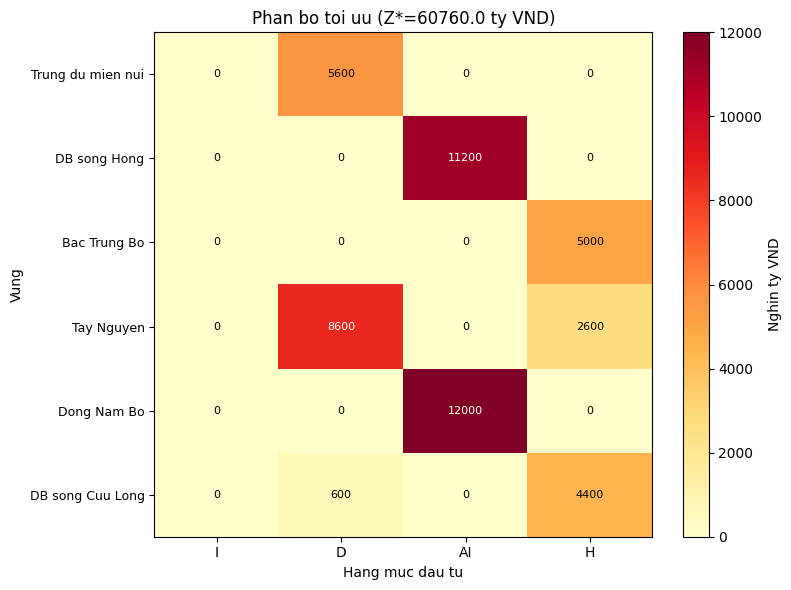

In [ ]:
import numpy as np
import pandas as pd
import pulp
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 4: Quy hoach tuyen tinh phan bo ngan sach theo vung
# ============================================================

regions = ['NMM', 'RRD', 'NCC', 'CH', 'SE', 'MD']
region_names = ['Trung du mien nui', 'DB song Hong', 'Bac Trung Bo',
                'Tay Nguyen', 'Dong Nam Bo', 'DB song Cuu Long']
items = ['I', 'D', 'AI', 'H']

beta = {
    ('NMM','I'):1.15, ('NMM','D'):0.85, ('NMM','AI'):0.55, ('NMM','H'):1.30,
    ('RRD','I'):0.95, ('RRD','D'):1.25, ('RRD','AI'):1.40, ('RRD','H'):1.05,
    ('NCC','I'):1.05, ('NCC','D'):0.95, ('NCC','AI'):0.85, ('NCC','H'):1.15,
    ('CH','I') :1.20, ('CH','D') :0.75, ('CH','AI') :0.45, ('CH','H') :1.35,
    ('SE','I') :0.90, ('SE','D') :1.30, ('SE','AI') :1.55, ('SE','H') :1.00,
    ('MD','I') :1.10, ('MD','D') :0.85, ('MD','AI') :0.65, ('MD','H') :1.25
}

# Doc D0 tu CSV
df_reg = pd.read_csv('vietnam_regions_2024.csv')
D0 = dict(zip(df_reg['region_name_en'].map(
    {'Northern Midlands and Mountains':'NMM','Red River Delta':'RRD',
     'North Central and South Central Coast':'NCC','Central Highlands':'CH',
     'Southeast':'SE','Mekong Delta':'MD'}),
    df_reg['digital_index_0_100']))
print(f"D0 doc tu CSV: {D0}")
# LUU Y: De bai goi y lam = 0 nhung lam=0 lam C5 vo hieu (trivially satisfied).
# Dung lam=0.6 de chi so so hoa moi vung >= 60% max → co y nghia cong bang.
# Don vi beta: ty VND GDP / ty VND dau tu (dimensionless ratio).
# Header de bai ghi "nghin VND / 1 trieu VND" la sai don vi, thuc te la ty/ty.
gamma_val, lam = 0.002, 0.6

# ============================================================
# Helper: giai bai toan LP
# ============================================================
def solve_lp(with_equity=True, verbose=True):
    m = pulp.LpProblem('VN_Digital_Budget', pulp.LpMaximize)
    x = pulp.LpVariable.dicts('x', (regions, items), lowBound=0)

    # Ham muc tieu
    m += pulp.lpSum(beta[(r,j)]*x[r][j] for r in regions for j in items), 'GDP_gain'

    # C1: Ngan sach tong
    m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000, 'C1_budget'

    # C2, C3: San/tran moi vung
    # C3 tran 12000 tac dong manh den ĐNB (beta_AI=1.55 cao nhat) -> ep cham tran
    for r in regions:
        m += pulp.lpSum(x[r][j] for j in items) >= 5000, f'C2_floor_{r}'
        m += pulp.lpSum(x[r][j] for j in items) <= 12000, f'C3_cap_{r}'

    # C4: San nhan luc so
    m += pulp.lpSum(x[r]['H'] for r in regions) >= 12000, 'C4_H_floor'

    # C5: Cong bang vung - D_r + gamma*x_D,r >= lam * max_r(D_r + gamma*x_D,r)
    # lam=0.6: chi so so hoa moi vung phai dat >= 60% vung tot nhat
    if with_equity:
        M = pulp.LpVariable('Dmax')
        for r in regions:
            m += D0[r] + gamma_val*x[r]['D'] <= M, f'C5_upper_{r}'
        for r in regions:
            m += D0[r] + gamma_val*x[r]['D'] >= lam*M, f'C5_lower_{r}'

    m.solve(pulp.PULP_CBC_CMD(msg=False))

    if verbose:
        print(f"Trang thai: {pulp.LpStatus[m.status]}")
        print(f"Z* = {pulp.value(m.objective):.2f} ty VND")

    # Lay ket qua
    result = np.zeros((6, 4))
    for i, r in enumerate(regions):
        for j_idx, j in enumerate(items):
            result[i, j_idx] = x[r][j].value()

    return result, pulp.value(m.objective), m

# ============================================================
# Cau 4.4.1: Giai bang PuLP (CBC)
# ============================================================
print("="*60)
print("CAU 4.4.1: Giai bang PuLP (CBC) - CO rang buoc cong bang")
print("="*60)

x_opt, Z_star, model = solve_lp(with_equity=True)

print("\nPhan bo toi uu x[j,r] (hang=cot=vung, cot=hang muc):")
header = f"{'Vung':<25}" + "".join(f"{j:>10}" for j in items) + f"{'Tong':>10}"
print(header)
print("-" * 65)
for i, (r, rn) in enumerate(zip(regions, region_names)):
    row_sum = x_opt[i].sum()
    row_str = f"{rn:<25}" + "".join(f"{x_opt[i,j]:>10.1f}" for j in range(4)) + f"{row_sum:>10.1f}"
    print(row_str)
col_totals = x_opt.sum(axis=0)
print("-" * 65)
print(f"{'Tong':<25}" + "".join(f"{col_totals[j]:>10.1f}" for j in range(4)) + f"{x_opt.sum():>10.1f}")

# Shadow prices
print("\nGia doi ngung (shadow prices):")
for name, constraint in model.constraints.items():
    if abs(constraint.pi) > 0.001 or abs(constraint.slack) < 0.01:
        print(f"  {name}: dual={constraint.pi:.4f}, slack={constraint.slack:.2f}")

# ============================================================
# Cau 4.4.2: Giai bang CVXPY
# ============================================================
print("\n" + "="*60)
print("CAU 4.4.2: Giai bang CVXPY - doi chieu ket qua")
print("="*60)

try:
    import cvxpy as cp

    x_cvx = cp.Variable((6, 4), nonneg=True)
    beta_mat = np.array([[beta[(r,j)] for j in items] for r in regions])

    objective = cp.Maximize(cp.sum(cp.multiply(beta_mat, x_cvx)))

    region_sums = cp.sum(x_cvx, axis=1)  # tong moi vung
    constraints = [
        cp.sum(x_cvx) <= 50000,           # C1
        region_sums >= 5000,               # C2
        region_sums <= 12000,              # C3
        cp.sum(x_cvx[:, 3]) >= 12000,     # C4 (H = cot 3)
    ]

    # C5: cong bang vung
    D0_vec = np.array([D0[r] for r in regions])
    D_new = D0_vec + gamma_val * x_cvx[:, 1]  # D = cot 1
    M_cvx = cp.Variable()
    constraints.append(D_new <= M_cvx)
    constraints.append(D_new >= lam * M_cvx)

    prob = cp.Problem(objective, constraints)
    # Thu cac solver chinh xac hon SCS
    for solver_name in ['CLARABEL', 'ECOS', 'SCS']:
        try:
            solver_obj = getattr(cp, solver_name, None)
            if solver_obj is None:
                continue
            prob.solve(solver=solver_obj, verbose=False)
            if prob.status in ['optimal', 'optimal_inaccurate']:
                print(f"CVXPY solver: {solver_name}, status: {prob.status}")
                break
        except Exception:
            continue

    print(f"CVXPY - Z* = {prob.value:.2f}")
    print(f"Chenh lech PuLP vs CVXPY = {abs(Z_star - prob.value):.4f}")

    print("\nPhan bo CVXPY:")
    print(header)
    print("-" * 65)
    for i, (r, rn) in enumerate(zip(regions, region_names)):
        row_sum = x_cvx.value[i].sum()
        row_str = f"{rn:<25}" + "".join(f"{x_cvx.value[i,j]:>10.1f}" for j in range(4)) + f"{row_sum:>10.1f}"
        print(row_str)

    # So sanh chi tiet
    print("\nChenh lech tuyet doi PuLP - CVXPY:")
    diff = np.abs(x_opt - x_cvx.value)
    print(f"Max chenh lech: {diff.max():.4f}")
    print(f"Mean chenh lech: {diff.mean():.4f}")

except ImportError:
    print("CVXPY chua duoc cai dat, bo qua.")

# ============================================================
# Cau 4.4.3: Heatmap phan bo toi uu
# ============================================================
print("\n" + "="*60)
print("CAU 4.4.3: Heatmap phan bo toi uu")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(x_opt, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(6))
ax.set_yticklabels(region_names, fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels(items)
ax.set_xlabel('Hang muc dau tu')
ax.set_ylabel('Vung')
ax.set_title(f'Phan bo toi uu (Z*={Z_star:.1f} ty VND)')
plt.colorbar(im, label='Nghin ty VND')

for i in range(6):
    for j in range(4):
        ax.text(j, i, f'{x_opt[i,j]:.0f}', ha='center', va='center', fontsize=8,
                color='white' if x_opt[i,j] > 8000 else 'black')

plt.tight_layout()
plt.savefig('bai4_heatmap_allocation.png', dpi=150)

print("\nVung nhan nhieu ngan sach nhat:")
region_totals = x_opt.sum(axis=1)
for i in np.argsort(region_totals)[::-1]:
    print(f"  {region_names[i]}: {region_totals[i]:.0f} ty VND")

print("\nHang muc uu tien tung vung:")
for i, rn in enumerate(region_names):
    best_item = items[np.argmax(x_opt[i])]
    print(f"  {rn}: {best_item} ({x_opt[i].max():.0f} ty)")

# ============================================================
# Cau 4.4.4: Doi chieu voi/khong cong bang
# ============================================================
print("\n" + "="*60)
print("CAU 4.4.4: Doi chieu - khong rang buoc cong bang (C5)")
print("="*60)

x_no_eq, Z_no_eq, _ = solve_lp(with_equity=False, verbose=False)

print(f"Z* CO cong bang:    {Z_star:.2f} ty VND")
print(f"Z* KHONG cong bang: {Z_no_eq:.2f} ty VND")
print(f"Chi phi cong bang:  {Z_no_eq - Z_star:.2f} ty VND")
print(f"                    ({(Z_no_eq - Z_star)/Z_no_eq*100:.2f}% Z*)")

print("\nPhan bo KHONG cong bang:")
print(header)
print("-" * 65)
for i, (r, rn) in enumerate(zip(regions, region_names)):
    row_sum = x_no_eq[i].sum()
    row_str = f"{rn:<25}" + "".join(f"{x_no_eq[i,j]:>10.1f}" for j in range(4)) + f"{row_sum:>10.1f}"
    print(row_str)

print("\nSo sanh tong theo vung:")
print(f"{'Vung':<25}{'Co CB':>10}{'Khong CB':>10}{'Chenh':>10}")
for i, rn in enumerate(region_names):
    eq_tot = x_opt[i].sum()
    noeq_tot = x_no_eq[i].sum()
    print(f"{rn:<25}{eq_tot:>10.0f}{noeq_tot:>10.0f}{noeq_tot-eq_tot:>10.0f}")


## Bài 5 — MIP chọn dự án

*File gốc: `bai5_mip_projects.py`*


In [ ]:
from pulp import *
import numpy as np

# ============================================================
# BAI 5: MIP lua chon du an chuyen doi so
# ============================================================

P = list(range(1, 16))

# Chi phi tong 5 nam (ty VND)
C = {1:12000, 2:11500, 3:18000, 4:4500, 5:3200, 6:5800, 7:6500, 8:15000,
     9:2500, 10:7200, 11:4800, 12:8500, 13:20000, 14:3800, 15:1500}

# Chi phi nam 1-2 (ty VND)
C1 = {1:8500, 2:7500, 3:12000, 4:3500, 5:2500, 6:4000, 7:4500, 8:9000,
      9:1800, 10:5000, 11:3500, 12:5500, 13:13000, 14:2800, 15:1200}

# Loi ich NPV (ty VND)
B = {1:21500, 2:20800, 3:32500, 4:9200, 5:6800, 6:11400, 7:12200, 8:28500,
     9:5800, 10:13800, 11:8500, 12:16200, 13:35000, 14:7500, 15:3800}

# Ten du an
names = {
    1: 'TT du lieu Hoa Lac', 2: 'TT du lieu phia Nam', 3: '5G toan quoc',
    4: 'VNeID 2.0', 5: 'Cong dich vu cong v3', 6: 'Y te so',
    7: 'Giao duc so K-12', 8: 'TT AI + supercomputing', 9: 'Fintech sandbox',
    10: 'Logistics thong minh', 11: 'Nong nghiep so DBSCL', 12: 'Dao tao 50K ky su AI',
    13: 'Khu CN ban dan BN-BG', 14: 'An ninh mang SOC', 15: 'Open Data'
}

# Lanh vuc (de xac dinh xac suất)
fields = {1:'ht', 2:'ht', 3:'ht', 4:'cp', 5:'cp', 6:'yt',
          7:'gd', 8:'ai', 9:'tc', 10:'lg', 11:'nn', 12:'nl',
          13:'bd', 14:'an', 15:'dl'}

# Xac suat hoan thanh dung tien do
prob = {'ht':0.85, 'cp':0.75, 'ai':0.65, 'bd':0.65,
        'yt':0.80, 'gd':0.80, 'tc':0.80, 'lg':0.80,
        'nn':0.80, 'nl':0.80, 'an':0.80, 'dl':0.80}

# ============================================================
# Cau 5.4.1: Giai bang PuLP (CBC)
# ============================================================
print("="*60)
print("CAU 5.4.1: MIP chon du an - PuLP CBC")
print("="*60)

def solve_mip(budget_total=80000, budget_12=40000, add_constraints=None, use_expected=False, exclude_dc=True):
    m = LpProblem('VN_Project_Selection', LpMaximize)
    y = LpVariable.dicts('y', P, cat='Binary')

    if use_expected:
        m += lpSum(prob[fields[i]] * B[i] * y[i] for i in P), 'Expected_benefit'
    else:
        m += lpSum(B[i] * y[i] for i in P), 'Total_benefit'

    # C1: Ngan sach tong 5 nam
    m += lpSum(C[i]*y[i] for i in P) <= budget_total, 'C1_budget_5y'
    # C2: Ngan sach nam 1-2
    m += lpSum(C1[i]*y[i] for i in P) <= budget_12, 'C2_budget_12'
    # C3: Loai tru TT du lieu (chi khi exclude_dc=True)
    if exclude_dc:
        m += y[1] + y[2] <= 1, 'C3_exclude_DC'
    # C4: Tien quyet AI can dao tao
    m += y[8] <= y[12], 'C4_AI_needs_training'
    # C5: Tien quyet ban dan can dao tao
    m += y[13] <= y[12], 'C5_semi_needs_training'
    # C6: Can doi linh vuc
    m += y[4] + y[5] >= 1, 'C6_gov_digital'
    m += y[14] >= 1, 'C6_cyber_required'
    # C7: So luong du an
    m += lpSum(y[i] for i in P) >= 7, 'C7_min_projects'
    m += lpSum(y[i] for i in P) <= 11, 'C7_max_projects'

    if add_constraints:
        add_constraints(m, y)

    m.solve(PULP_CBC_CMD(msg=False))

    selected = [i for i in P if y[i].value() > 0.5]
    total_cost = sum(C[i] for i in selected)
    total_cost_12 = sum(C1[i] for i in selected)
    Z = value(m.objective)

    return selected, total_cost, total_cost_12, Z, m

selected, total_cost, total_cost_12, Z, model = solve_mip()

print(f"Trang thai: {LpStatus[model.status]}")
print(f"So du an chon: {len(selected)}")
print(f"\nCac du an duoc chon:")
print(f"{'Ma':<5} {'Ten du an':<35} {'Chi phi':>8} {'NPV':>8} {'NPV/C':>6} {'Nam 1-2':>8}")
print("-" * 75)
for i in selected:
    ratio = B[i] / C[i]
    print(f"P{i:<4} {names[i]:<35} {C[i]:>8,} {B[i]:>8,} {ratio:>6.2f} {C1[i]:>8,}")

print(f"\nTong chi phi 5 nam: {total_cost:,} ty VND")
print(f"Tong chi phi nam 1-2: {total_cost_12:,} ty VND")
print(f"Tong loi ich NPV (Z*): {Z:,.0f} ty VND")
print(f"B/C trung binh (Z*/chi phi): {Z/total_cost:.2f}")
# LUU Y: P15 (Open Data) CO duoc chon vi B/C=2.53 cao nhat.
# Cau 5.5.a cua de bai dat gia thiet "mo hinh bo qua P15" la SAI.

# ============================================================
# Cau 5.4.2: Noi ngan sach len 100,000 ty
# ============================================================
print("\n" + "="*60)
print("CAU 5.4.2: Noi ngan sach len 100,000 ty")
print("="*60)

s2, tc2, tc12_2, Z2, _ = solve_mip(budget_total=100000, budget_12=40000)
print(f"Du an chon: {s2}")
print(f"Z* = {Z2:,.0f} ty VND (tang {Z2-Z:,.0f} ty)")
print(f"Chi phi = {tc2:,} ty VND")

new_projects = set(s2) - set(selected)
removed_projects = set(selected) - set(s2)
if new_projects:
    print(f"Du an moi: {['P'+str(i) for i in new_projects]}")
if removed_projects:
    print(f"Du an bo: {['P'+str(i) for i in removed_projects]}")

# ============================================================
# Cau 5.4.3: Bat buoc P1 va P2
# ============================================================
print("\n" + "="*60)
print("CAU 5.4.3: Bat buoc ca P1 va P2 (redundancy)")
print("="*60)

def force_p1_p2(m, y):
    m += y[1] >= 1, 'Force_P1'
    m += y[2] >= 1, 'Force_P2'

s3, tc3, tc12_3, Z3, m3 = solve_mip(add_constraints=force_p1_p2, exclude_dc=False)
print(f"Trang thai: {LpStatus[m3.status]}")
if m3.status == 1:
    print(f"(Ghi: C3 loai tru P1/P2 duoc thay bang yeu cau chon ca P1 va P2)")
    print(f"Du an chon: {s3}")
    print(f"Z* = {Z3:,.0f} ty VND (giam {Z-Z3:,.0f} ty so voi ban dau)")
    print(f"Chi phi = {tc3:,} ty VND")
    print(f"Chi phi nam 1-2 = {tc12_3:,} ty VND")
else:
    print("Bai toan KHONG kha thi!")

# ============================================================
# Cau 5.4.4: Them rui ro du an (expected benefit)
# ============================================================
print("\n" + "="*60)
print("CAU 5.4.4: Toi da hoan loi ich ky vong E[Z] = sum(p_i * B_i * y_i)")
print("="*60)

print("\nXac suat hoan thanh:")
for field_name, p_val in sorted(set(prob.items()), key=lambda x: x[1]):
    projects = [f"P{i}" for i in P if fields[i] == field_name]
    print(f"  {field_name}: p={p_val} -> {projects}")

s4, tc4, tc12_4, Z4, _ = solve_mip(use_expected=True)
print(f"\nDu an chon (expected): {s4}")
print(f"E[Z] = {Z4:,.0f} ty VND")
print(f"Chi phi = {tc4:,} ty VND")

# So sanh
print(f"\nSo sanh:")
print(f"  Deterministic: Z*={Z:,.0f}, du an={selected}")
print(f"  Expected:      E[Z]={Z4:,.0f}, du an={s4}")

diff = set(selected) - set(s4)
if diff:
    print(f"  Du an bi loai bo khi co rui ro: {['P'+str(i) for i in diff]}")
diff2 = set(s4) - set(selected)
if diff2:
    print(f"  Du an duoc them khi co rui ro: {['P'+str(i) for i in diff2]}")

# Chi tiet loi ich ky vong tung du an
print(f"\nChi tiet loi ich ky vong (p_i * B_i):")
print(f"{'Ma':<5} {'p_i':>5} {'B_i':>8} {'E[B_i]':>8} {'C_i':>8} {'E[B]/C':>7}")
print("-" * 50)
for i in P:
    e_b = prob[fields[i]] * B[i]
    print(f"P{i:<4} {prob[fields[i]]:>5.2f} {B[i]:>8,} {e_b:>8,.0f} {C[i]:>8,} {e_b/C[i]:>7.2f}")


CAU 5.4.1: MIP chon du an - PuLP CBC
Trang thai: Optimal
So du an chon: 9

Cac du an duoc chon:
Ma    Ten du an                            Chi phi      NPV  NPV/C  Nam 1-2
---------------------------------------------------------------------------
P2    TT du lieu phia Nam                   11,500   20,800   1.81    7,500
P5    Cong dich vu cong v3                   3,200    6,800   2.12    2,500
P7    Giao duc so K-12                       6,500   12,200   1.88    4,500
P8    TT AI + supercomputing                15,000   28,500   1.90    9,000
P9    Fintech sandbox                        2,500    5,800   2.32    1,800
P10   Logistics thong minh                   7,200   13,800   1.92    5,000
P12   Dao tao 50K ky su AI                   8,500   16,200   1.91    5,500
P14   An ninh mang SOC                       3,800    7,500   1.97    2,800
P15   Open Data                              1,500    3,800   2.53    1,200

Tong chi phi 5 nam: 59,700 ty VND
Tong chi phi nam 1-2: 39,800 ty V

## Bài 6 — TOPSIS xếp hạng vùng

*File gốc: `bai6_topsis.py`*


CAU 6.4.1: TOPSIS voi trong so chuyen gia

Trong so chuyen gia: {'GRDP/N': np.float64(0.1), 'FDI': np.float64(0.1), 'Digital': np.float64(0.15), 'AI': np.float64(0.2), 'LĐĐT': np.float64(0.15), 'R&D': np.float64(0.15), 'Internet': np.float64(0.05), 'Gini': np.float64(0.1)}

Hang  Vung                                 C*
---------------------------------------------
1     Southeast                        0.9402
2     Red River Delta                  0.8981
3     North Central and South Central Coast   0.3597
4     Mekong Delta                     0.1710
5     Northern Midlands and Mountains   0.0993
6     Central Highlands                0.0312

CAU 6.4.2: TOPSIS voi trong so Entropy

Trong so Entropy:
  GRDP/N: 0.0787
  FDI: 0.4151
  Digital: 0.0597
  AI: 0.1390
  LĐĐT: 0.0628
  R&D: 0.2361
  Internet: 0.0073
  Gini: 0.0012
  Tong: 1.0000

Hang  Vung                           C*_entropy
-----------------------------------------------
1     Red River Delta                    0.9690
2    

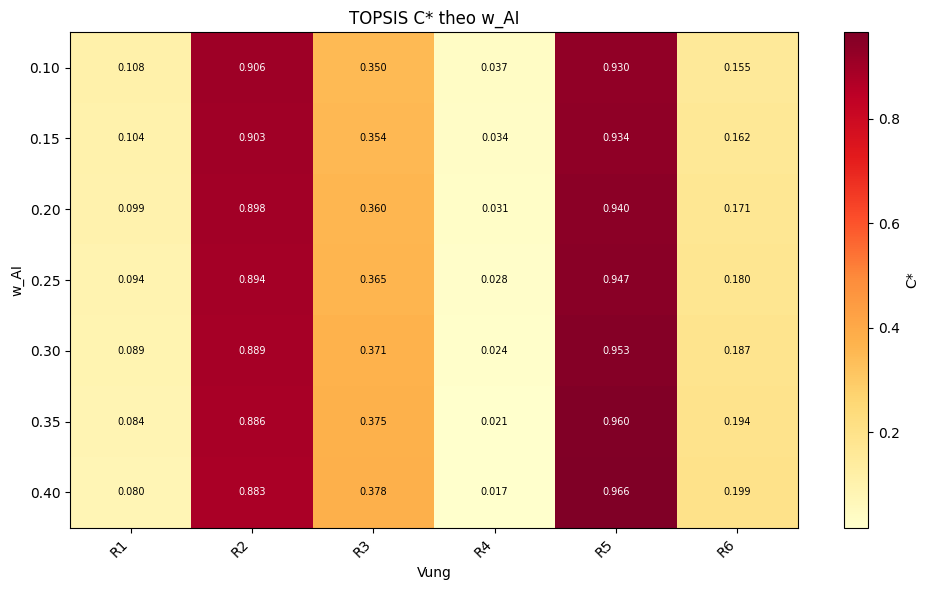

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 6: TOPSIS xep hang 6 vung theo uu tien dau tu AI
# ============================================================

df = pd.read_csv('vietnam_regions_2024.csv')
region_names = df['region_name_en'].tolist()

criteria = ['grdp_per_capita_million_VND', 'fdi_registered_billion_USD',
            'digital_index_0_100', 'ai_readiness_0_100',
            'trained_labor_pct', 'rd_intensity_pct',
            'internet_penetration_pct', 'gini_coef']

criteria_labels = ['GRDP/N', 'FDI', 'Digital', 'AI', 'LĐĐT', 'R&D', 'Internet', 'Gini']
is_benefit = [True, True, True, True, True, True, True, False]

X = df[criteria].values.astype(float)

# ============================================================
# Cau 6.4.1: TOPSIS voi trong so chuyen gia
# ============================================================
print("="*60)
print("CAU 6.4.1: TOPSIS voi trong so chuyen gia")
print("="*60)

w_expert = np.array([0.10, 0.10, 0.15, 0.20, 0.15, 0.15, 0.05, 0.10])

def topsis(X, w, is_benefit):
    # B1: Chuan hoa vector
    R = X / np.sqrt((X**2).sum(axis=0))
    # B2: Nhan trong so
    V = R * w
    # B3: Ly tuong duong/am
    A_star = np.where(is_benefit, V.max(axis=0), V.min(axis=0))
    A_neg = np.where(is_benefit, V.min(axis=0), V.max(axis=0))
    # B4: Khoang cach Euclide
    S_star = np.sqrt(((V - A_star)**2).sum(axis=1))
    S_neg = np.sqrt(((V - A_neg)**2).sum(axis=1))
    # B5: He so gan gu
    C_star = S_neg / (S_star + S_neg)
    return C_star, S_star, S_neg, V, A_star, A_neg

C_star, S_star, S_neg, V, A_star, A_neg = topsis(X, w_expert, is_benefit)

df['TOPSIS_expert'] = C_star
rank_expert = df[['region_name_en'] + criteria + ['TOPSIS_expert']].copy()
rank_expert['Rank'] = rank_expert['TOPSIS_expert'].rank(ascending=False).astype(int)
rank_expert = rank_expert.sort_values('Rank')

print("\nTrong so chuyen gia:", dict(zip(criteria_labels, w_expert)))
print(f"\n{'Hang':<5} {'Vung':<30} {'C*':>8}")
print("-" * 45)
for _, row in rank_expert.iterrows():
    print(f"{row['Rank']:<5} {row['region_name_en']:<30} {row['TOPSIS_expert']:>8.4f}")

# ============================================================
# Cau 6.4.2: TOPSIS voi trong so Entropy
# ============================================================
print("\n" + "="*60)
print("CAU 6.4.2: TOPSIS voi trong so Entropy")
print("="*60)

def entropy_weights(X):
    P = X / X.sum(axis=0)
    k = 1.0 / np.log(len(X))
    E = -k * np.nansum(P * np.log(P + 1e-12), axis=0)
    d = 1 - E
    return d / d.sum()

w_entropy = entropy_weights(X)
C_star_ent, _, _, _, _, _ = topsis(X, w_entropy, is_benefit)

df['TOPSIS_entropy'] = C_star_ent

print("\nTrong so Entropy:")
for lab, w_e in zip(criteria_labels, w_entropy):
    print(f"  {lab}: {w_e:.4f}")
print(f"  Tong: {w_entropy.sum():.4f}")

print(f"\n{'Hang':<5} {'Vung':<30} {'C*_entropy':>10}")
print("-" * 47)
rank_ent = df[['region_name_en', 'TOPSIS_entropy']].copy()
rank_ent['Rank'] = rank_ent['TOPSIS_entropy'].rank(ascending=False).astype(int)
rank_ent = rank_ent.sort_values('Rank')
for _, row in rank_ent.iterrows():
    print(f"{row['Rank']:<5} {row['region_name_en']:<30} {row['TOPSIS_entropy']:>10.4f}")

# So sanh 2 phuong phap
print("\nSo sanh xep hang:")
print(f"{'Vung':<30} {'Expert':>8} {'Entropy':>8} {'Chenh':>6}")
print("-" * 55)
for i, rn in enumerate(region_names):
    r1 = int(rank_expert[rank_expert['region_name_en']==rn]['Rank'].values[0])
    r2 = int(rank_ent[rank_ent['region_name_en']==rn]['Rank'].values[0])
    print(f"{rn:<30} {r1:>8} {r2:>8} {r2-r1:>+6}")

# ============================================================
# Cau 6.4.3: Phan tich do nhay w_AI
# ============================================================
print("\n" + "="*60)
print("CAU 6.4.3: Phan tich do nhay w_AI (0.10 -> 0.40)")
print("="*60)

# Cot AI Readiness la cot thu 3 (index 3)
ai_idx = 3
w_ai_range = np.arange(0.10, 0.45, 0.05)
top3_history = []
heatmap_scores = []

for w_ai in w_ai_range:
    # Chuan hoa lai: w_ai thay doi, cac cot con lai giu ty le goc
    # Cac cot tru AI va Gini: [0.10, 0.10, 0.15, 0.15, 0.15, 0.05] -> tong = 0.70
    # Gini giu co dinh 0.10
    w_gini = 0.10
    remaining = 1.0 - w_ai - w_gini
    w_base = np.array([0.10, 0.10, 0.15, 0.15, 0.15, 0.05])  # 6 cot (tru AI, tru Gini)
    w_scaled = w_base * (remaining / w_base.sum())
    # Chen AI vao vi tri index 3
    w_full = np.insert(w_scaled, ai_idx, w_ai)
    # Them Gini
    w_full = np.append(w_full, w_gini)

    C_s, _, _, _, _, _ = topsis(X, w_full, is_benefit)
    heatmap_scores.append(C_s)

    top3_idx = np.argsort(C_s)[-3:][::-1]
    top3_names = [region_names[j] for j in top3_idx]
    top3_history.append(top3_names)

heatmap_scores = np.array(heatmap_scores)

print("\nTop-3 theo tung w_AI:")
for i, w_ai in enumerate(w_ai_range):
    print(f"  w_AI={w_ai:.2f}: {top3_history[i]}")

all_same = all(t == top3_history[0] for t in top3_history)
print(f"\nTop-3 on dinh? {'CO' if all_same else 'KHONG'}")

# Ve heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_scores, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(w_ai_range)))
ax.set_yticklabels([f'{w:.2f}' for w in w_ai_range])
ax.set_xticks(range(6))
ax.set_xticklabels([f'R{i+1}' for i in range(6)], rotation=45, ha='right')
ax.set_xlabel('Vung')
ax.set_ylabel('w_AI')
ax.set_title('TOPSIS C* theo w_AI')
plt.colorbar(im, label='C*')

for i in range(len(w_ai_range)):
    for j in range(6):
        ax.text(j, i, f'{heatmap_scores[i,j]:.3f}', ha='center', va='center', fontsize=7,
                color='white' if heatmap_scores[i,j] > 0.4 else 'black')

plt.tight_layout()
plt.savefig('bai6_topsis_sensitivity.png', dpi=150)

# ============================================================
# Cau 6.4.4: AHP don gian so sanh voi TOPSIS
# ============================================================
print("\n" + "="*60)
print("CAU 6.4.4: AHP don gian so sanh voi TOPSIS")
print("="*60)

# Ma tran so sanh cap (8x8) cho 8 tieu chi
# Thu tu: GRDP, FDI, Digital, AI, LĐĐT, R&D, Internet, Gini
# AHP: AI (5) > Digital (4) > LĐĐT (3) = R&D (3) > GRDP (2) = FDI (2) > Internet (1) = Gini (1)
# Ma tran so sanh doi voi (1-9 scale)
ahp_matrix = np.array([
    # GRDP  FDI  Dig  AI   LĐĐT  R&D  Int  Gini
    [1,    1,   1/3, 1/5, 1/3,  1/3, 3,   3   ],  # GRDP
    [1,    1,   1/3, 1/5, 1/3,  1/3, 3,   3   ],  # FDI
    [3,    3,   1,   1/2, 1,    1,   5,   5   ],  # Digital
    [5,    5,   2,   1,   2,    2,   7,   7   ],  # AI
    [3,    3,   1,   1/2, 1,    1,   5,   5   ],  # LĐĐT
    [3,    3,   1,   1/2, 1,    1,   5,   5   ],  # R&D
    [1/3,  1/3, 1/5, 1/7, 1/5,  1/5, 1,   1   ],  # Internet
    [1/3,  1/3, 1/5, 1/7, 1/5,  1/5, 1,   1   ],  # Gini
])

# Tinh trong so AHP (geometric mean method)
n = ahp_matrix.shape[0]
geo_mean = np.prod(ahp_matrix, axis=1) ** (1/n)
w_ahp = geo_mean / geo_mean.sum()

# Kiem tra nhat quan (CR)
Aw = ahp_matrix @ w_ahp
lambda_max = np.mean(Aw / w_ahp)
CI = (lambda_max - n) / (n - 1)
RI = 1.41  # RI cho n=8
CR = CI / RI

print("\nTrong so AHP:")
for lab, w_a in zip(criteria_labels, w_ahp):
    print(f"  {lab}: {w_a:.4f}")
print(f"\nlambda_max = {lambda_max:.4f}")
print(f"CI = {CI:.4f}")
print(f"CR = {CR:.4f} ({'Nhat quan' if CR < 0.10 else 'CHUA nhat quan'})")

C_star_ahp, _, _, _, _, _ = topsis(X, w_ahp, is_benefit)
df['TOPSIS_AHP'] = C_star_ahp

rank_ahp = df[['region_name_en', 'TOPSIS_AHP']].copy()
rank_ahp['Rank'] = rank_ahp['TOPSIS_AHP'].rank(ascending=False).astype(int)
rank_ahp = rank_ahp.sort_values('Rank')

print(f"\n{'Hang':<5} {'Vung':<30} {'C*_AHP':>8}")
print("-" * 45)
for _, row in rank_ahp.iterrows():
    print(f"{row['Rank']:<5} {row['region_name_en']:<30} {row['TOPSIS_AHP']:>8.4f}")

# So sanh 3 phuong phap
print("\nSo sanh 3 phuong phap:")
print(f"{'Vung':<30} {'Expert':>8} {'Entropy':>8} {'AHP':>8}")
print("-" * 56)
for rn in region_names:
    r1 = int(rank_expert[rank_expert['region_name_en']==rn]['Rank'].values[0])
    r2 = int(rank_ent[rank_ent['region_name_en']==rn]['Rank'].values[0])
    r3 = int(rank_ahp[rank_ahp['region_name_en']==rn]['Rank'].values[0])
    print(f"{rn:<30} {r1:>8} {r2:>8} {r3:>8}")


## Bài 7 — NSGA-II đa mục tiêu Pareto

*File gốc: `bai7_nsga2.py`*


BÀI 7: NSGA-II đa mục tiêu
So nghiem Pareto: 100

Thong ke 4 muc tieu:
  f1 (GDP gain, -max): [43558, 54060]
  f2 (Gini/MAD):       [219.4, 2245.9]
  f3 (phat thai):      [5853, 12857]
  f4 (rui ro rong):    [-9511, -1956]

CAU 7.4.3: TOPSIS tren tap Pareto
Nghiem thoa hiep (TOPSIS):
  f1 GDP gain = 51660 ty VND
  f2 Gini/MAD = 549.7
  f3 Phat thai = 8786
  f4 Rui ro = -5911
  C* = 0.7281

Phan bo toi uu:
Vung               I         D        AI         H      Tong
-------------------------------------------------------
NMM              223      5811        17      2183      8234
RRD              230        32      1311      6425      7999
NCC               22        82       257      6739      7100
CH               109      8648       108        92      8957
SE                49        10      2738      6355      9152
MD                18      1607        46      6275      7946
Tong             653     16189      4477     28070     49389

CAU 7.4.4: Chi phi co hoi - nghiem tang truong

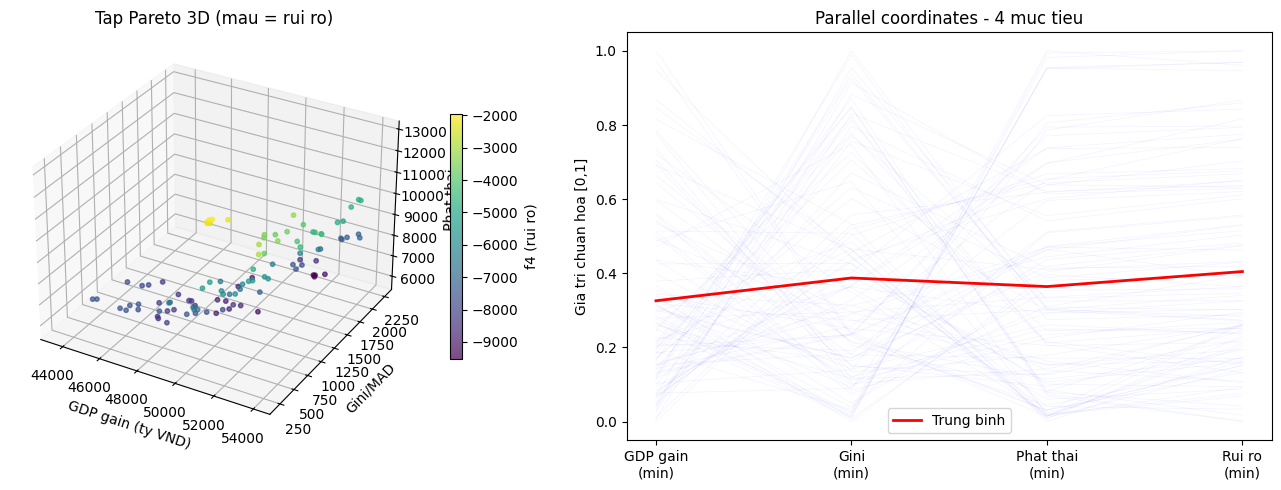

In [ ]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 7: Toi uu da muc tieu Pareto voi NSGA-II
# ============================================================

regions = ['NMM', 'RRD', 'NCC', 'CH', 'SE', 'MD']
items = ['I', 'D', 'AI', 'H']

beta = np.array([
    [1.15, 0.85, 0.55, 1.30],  # NMM
    [0.95, 1.25, 1.40, 1.05],  # RRD
    [1.05, 0.95, 0.85, 1.15],  # NCC
    [1.20, 0.75, 0.45, 1.35],  # CH
    [0.90, 1.30, 1.55, 1.00],  # SE
    [1.10, 0.85, 0.65, 1.25],  # MD
])

D0 = np.array([38, 78, 55, 32, 82, 48])
e = np.array([0.42, 0.55, 0.48, 0.32, 0.62, 0.38])
rho = np.array([0.18, 0.45, 0.28, 0.12, 0.52, 0.22])
sig = np.array([0.32, 0.28, 0.30, 0.35, 0.25, 0.30])
gamma_val = 0.002
lam_val = 0.6

class VietnamDigitalProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=24, n_obj=4, n_ieq_constr=20,
                         xl=np.zeros(24), xu=np.ones(24)*12000)

    def _evaluate(self, x, out, *args, **kwargs):
        X = x.reshape(6, 4)

        # f1: max GDP gain (dang min nen doi dau)
        f1 = -(beta * X).sum()

        # f2: Gini xap xi bang MAD thô (mean absolute deviation)
        sums = X.sum(axis=1)
        f2 = np.abs(sums - sums.mean()).mean()

        # f3: phat thai (I + D + AI — data center, server farm cung phat thai)
        f3 = (e * (X[:, 0] + X[:, 1] + X[:, 2])).sum()

        # f4: rui ro rong = rho*xAI - sig*xH
        # LUU Y: f4 co the am vo han khi xH >> xAI → "net safety" thay vi "net risk"
        # Khi minimize, NSGA-II ep xH max, xAI min → tap Pareto co the degenerate
        f4 = (rho * X[:, 2]).sum() - (sig * X[:, 3]).sum()

        out['F'] = [f1, f2, f3, f4]

        # Rang buoc
        g = []
        # C1: ngan sach tong
        g.append(X.sum() - 50000)
        # C2: san moi vung
        for r in range(6):
            g.append(5000 - X[r].sum())
        # C3: tran moi vung
        for r in range(6):
            g.append(X[r].sum() - 12000)
        # C4: san nhan luc
        g.append(12000 - X[:, 3].sum())
        # C5: cong bang vung — NSGA-II khong can linearize (gradient-free),
        # dung truc tiep D_new[r] >= lam * max(D_new)
        D_new = D0 + gamma_val * X[:, 1]  # D = cot index 1
        D_max = D_new.max()
        for r in range(6):
            g.append(lam_val * D_max - D_new[r])  # D_new[r] >= lam * D_max

        out['G'] = np.array(g)

print("="*60)
print("BÀI 7: NSGA-II đa mục tiêu")
print("="*60)

problem = VietnamDigitalProblem()
algorithm = NSGA2(pop_size=100)
termination = get_termination("n_gen", 200)

res = minimize(problem, algorithm, termination, seed=42, verbose=False)

F = res.F
X = res.X

print(f"So nghiem Pareto: {len(F)}")
print(f"\nThong ke 4 muc tieu:")
print(f"  f1 (GDP gain, -max): [{-F[:,0].max():.0f}, {-F[:,0].min():.0f}]")
print(f"  f2 (Gini/MAD):       [{F[:,1].min():.1f}, {F[:,1].max():.1f}]")
print(f"  f3 (phat thai):      [{F[:,2].min():.0f}, {F[:,2].max():.0f}]")
print(f"  f4 (rui ro rong):    [{F[:,3].min():.0f}, {F[:,3].max():.0f}]")

# ============================================================
# Cau 7.4.2: Scatter 3D va parallel coordinates
# ============================================================
fig = plt.figure(figsize=(14, 5))

# Scatter 3D f1 vs f2 vs f3
ax1 = fig.add_subplot(121, projection='3d')
sc = ax1.scatter(-F[:,0], F[:,1], F[:,2], c=F[:,3], cmap='viridis', s=10, alpha=0.7)
ax1.set_xlabel('GDP gain (ty VND)')
ax1.set_ylabel('Gini/MAD')
ax1.set_zlabel('Phat thai')
ax1.set_title('Tap Pareto 3D (mau = rui ro)')
plt.colorbar(sc, ax=ax1, label='f4 (rui ro)', shrink=0.6)

# Parallel coordinates
ax2 = fig.add_subplot(122)
F_norm = np.copy(F)
for i in range(4):
    fmin, fmax = F[:, i].min(), F[:, i].max()
    if fmax > fmin:
        F_norm[:, i] = (F[:, i] - fmin) / (fmax - fmin)
    else:
        F_norm[:, i] = 0.5

for i in range(len(F)):
    ax2.plot(range(4), F_norm[i], 'b-', alpha=0.05, linewidth=0.5)

# Ve nghiem trung binh
mean_norm = F_norm.mean(axis=0)
ax2.plot(range(4), mean_norm, 'r-', linewidth=2, label='Trung binh')

ax2.set_xticks(range(4))
ax2.set_xticklabels(['GDP gain\n(min)', 'Gini\n(min)', 'Phat thai\n(min)', 'Rui ro\n(min)'])
ax2.set_ylabel('Gia tri chuan hoa [0,1]')
ax2.set_title('Parallel coordinates - 4 muc tieu')
ax2.legend()

plt.tight_layout()
plt.savefig('bai7_pareto.png', dpi=150)

# ============================================================
# Cau 7.4.3: TOPSIS tren tap Pareto -> chon nghiem thoa hiep
# ============================================================
print("\n" + "="*60)
print("CAU 7.4.3: TOPSIS tren tap Pareto")
print("="*60)

# Trong so: GDP(0.40), Gini(0.25), M.Truong(0.20), An ninh(0.15)
w_policy = np.array([0.40, 0.25, 0.20, 0.15])

# Tat ca la minimize (f1 da doi dau thanh -max nen cung la min)
# Dung min-max normalization thay cho vector normalization vi f4 co the am.
# Vector norm (F/sqrt(sumF^2)) van chay nhung intuition sai khi co gia tri am.
fmin = F.min(axis=0)
fmax = F.max(axis=0)
frange = np.where(fmax - fmin > 1e-12, fmax - fmin, 1.0)
R = (F - fmin) / frange  # R in [0, 1], 0 = best (min), 1 = worst
V = R * w_policy

# Sau min-max: A_star = 0 (best), A_neg = w_policy (worst)
A_star = np.zeros_like(w_policy)
A_neg = w_policy.copy()

S_star = np.sqrt(((V - A_star)**2).sum(axis=1))
S_neg = np.sqrt(((V - A_neg)**2).sum(axis=1))
C_star = S_neg / (S_star + S_neg)

best_idx = np.argmax(C_star)
best_x = X[best_idx]
best_F = F[best_idx]

print(f"Nghiem thoa hiep (TOPSIS):")
print(f"  f1 GDP gain = {-best_F[0]:.0f} ty VND")
print(f"  f2 Gini/MAD = {best_F[1]:.1f}")
print(f"  f3 Phat thai = {best_F[2]:.0f}")
print(f"  f4 Rui ro = {best_F[3]:.0f}")
print(f"  C* = {C_star[best_idx]:.4f}")

print(f"\nPhan bo toi uu:")
best_X = best_x.reshape(6, 4)
header = f"{'Vung':<10}" + "".join(f"{j:>10}" for j in items) + f"{'Tong':>10}"
print(header)
print("-" * 55)
for i, r in enumerate(regions):
    row = f"{r:<10}" + "".join(f"{best_X[i,j]:>10.0f}" for j in range(4)) + f"{best_X[i].sum():>10.0f}"
    print(row)
print(f"{'Tong':<10}" + "".join(f"{best_X[:,j].sum():>10.0f}" for j in range(4)) + f"{best_X.sum():>10.0f}")

# ============================================================
# Cau 7.4.4: Chi phi co hoi
# ============================================================
print("\n" + "="*60)
print("CAU 7.4.4: Chi phi co hoi - nghiem tang truong cao nhat")
print("="*60)

max_growth_idx = np.argmin(F[:, 0])  # f1 min = -max growth
max_growth_F = F[max_growth_idx]
max_growth_x = X[max_growth_idx].reshape(6, 4)

print(f"\nNghiem tang truong cao nhat:")
print(f"  f1 GDP gain = {-max_growth_F[0]:.0f} ty VND")
print(f"  f2 Gini/MAD = {max_growth_F[1]:.1f}")
print(f"  f3 Phat thai = {max_growth_F[2]:.0f}")
print(f"  f4 Rui ro   = {max_growth_F[3]:.0f}")

print(f"\nNghiem thoa hiep:")
print(f"  f1 GDP gain = {-best_F[0]:.0f} ty VND")
print(f"  f2 Gini/MAD = {best_F[1]:.1f}")
print(f"  f3 Phat thai = {best_F[2]:.0f}")
print(f"  f4 Rui ro   = {best_F[3]:.0f}")

print(f"\nChi phi co hoi (tang truong vs thoa hiep):")
if best_F[1] > 0:
    gini_change = (max_growth_F[1] - best_F[1]) / best_F[1] * 100
else:
    gini_change = 0
if best_F[2] > 0:
    emit_change = (max_growth_F[2] - best_F[2]) / best_F[2] * 100
else:
    emit_change = 0

print(f"  GDP gain tang: {(-max_growth_F[0]) - (-best_F[0]):+.0f} ty VND ({((-max_growth_F[0]) - (-best_F[0]))/(-best_F[0])*100:+.1f}%)")
print(f"  Gini tang: {gini_change:+.1f}%")
print(f"  Phat thai tang: {emit_change:+.1f}%")
print(f"  Rui ro tang: {(max_growth_F[3] - best_F[3]):+.0f}")

# Ghi chu: nghiem tang truong cao nhat hien o dau
print(f"\nPhan bo nghiem tang truong cao nhat:")
header2 = f"{'Vung':<10}" + "".join(f"{j:>10}" for j in items) + f"{'Tong':>10}"
print(header2)
print("-" * 55)
for i, r in enumerate(regions):
    row = f"{r:<10}" + "".join(f"{max_growth_x[i,j]:>10.0f}" for j in range(4)) + f"{max_growth_x[i].sum():>10.0f}"
    print(row)


## Bài 8 — Tối ưu động liên thời gian

*File gốc: `bai8_dynamic_opt.py`*


BÀI 8: Tối ưu động 2026-2035

Phuc loi W* = 17.41

Nam             K        D       AI        H        TFP          Y          C
------------------------------------------------------------------------
2026        27500     20.3     86.0     30.0      33.70      12848      10748
2027        26965    542.9    493.1    281.4      33.82      24023      21923
2028        26457   1002.7    839.1    527.8      35.09      28821      26721
2029        25974   1407.4   1133.3    769.2      37.47      33411      31311
2030        25515   1763.5   1383.3   1005.8      41.06      38683      36583
2031        25079   2076.9   1595.8   1237.7      46.02      45143      43043
2032        24665   2352.7   1776.4   1465.0      52.63      53263      51163
2033        24272   2595.3   1930.0   1687.7      61.30      63594      61494
2034        23899   2808.9   2060.5   1905.9      72.58      76837      74737
2035        23544   2996.8   2171.4   2119.8      87.21      93914      91814
2036        23206 

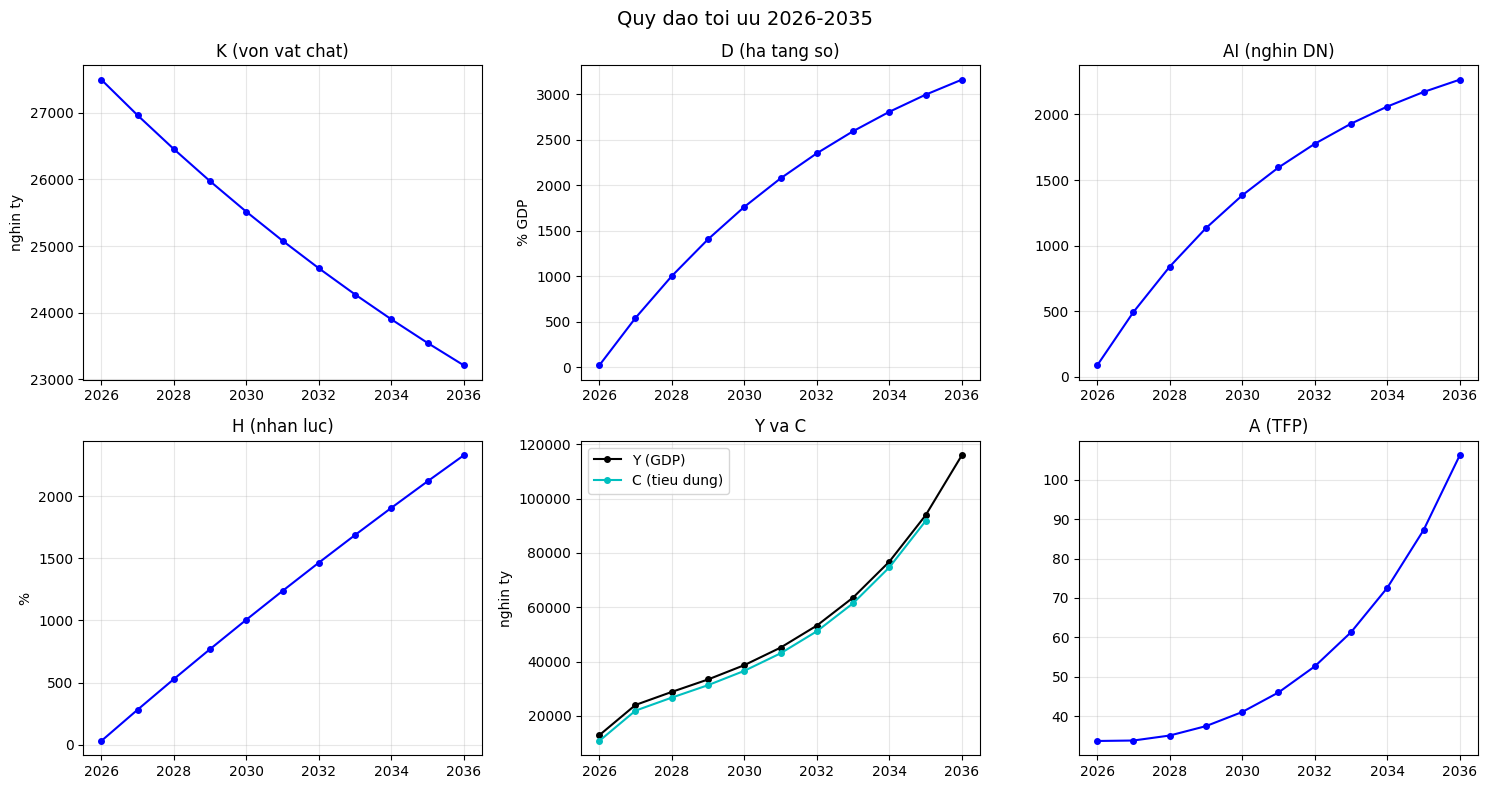

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 8: Toi uu dong phan bo lien thoi gian 2026-2035
# ============================================================

alpha, beta_cd, gamma_d, delta_ai, theta_h = 0.33, 0.42, 0.10, 0.08, 0.07
delta_K, delta_D, delta_AI = 0.05, 0.12, 0.15
theta_H_eff, mu = 0.8, 0.02
phi1, phi2, phi3 = 0.003, 0.002, 0.004
rho_disc = 0.97
gamma_cr = 1.5
T = 10
years = np.arange(2026, 2026+T+1)

K0, L0, D0, AI0, H0 = 27500.0, 53.9, 20.3, 86.0, 30.0
Y0 = 12847.6
A0 = Y0 / (K0**alpha * L0**beta_cd * D0**gamma_d * AI0**delta_ai * H0**theta_h)
L = np.array([L0 * 1.009**t for t in range(T+1)])

def compute_trajectory(u, shock_year=None, shock_pct=0.0):
    IK = u[0::4]; ID = u[1::4]; IAI = u[2::4]; IH = u[3::4]
    K = np.zeros(T+1); D = np.zeros(T+1); AI = np.zeros(T+1)
    H = np.zeros(T+1); A = np.zeros(T+1); Y = np.zeros(T+1); C = np.zeros(T)
    K[0]=K0; D[0]=D0; AI[0]=AI0; H[0]=H0; A[0]=A0

    for t in range(T):
        # Shock A_t (TFP) tai nam soc → anh huong keo dai qua dong hoc A[t+1]=A[t]*(1+growth)
        if shock_year is not None and t == shock_year:
            A[t] *= (1 - shock_pct)
        Y[t] = A[t]*K[t]**alpha*L[t]**beta_cd*D[t]**gamma_d*AI[t]**delta_ai*H[t]**theta_h
        C[t] = Y[t] - IK[t] - ID[t] - IAI[t] - IH[t]
        if C[t] <= 0: return None
        K[t+1] = (1-delta_K)*K[t] + IK[t]
        D[t+1] = (1-delta_D)*D[t] + ID[t]
        AI[t+1] = (1-delta_AI)*AI[t] + IAI[t]
        H[t+1] = H[t] + theta_H_eff*IH[t] - mu*H[t]
        A[t+1] = A[t]*(1 + phi1*(D[t]/100) + phi2*(AI[t]/100) + phi3*(H[t]/100))
    Y[T] = A[T]*K[T]**alpha*L[T]**beta_cd*D[T]**gamma_d*AI[T]**delta_ai*H[T]**theta_h
    return K, D, AI, H, Y, C, A

def welfare(u, shock_year=None, shock_pct=0.0):
    result = compute_trajectory(u, shock_year, shock_pct)
    if result is None: return 1e15
    K, D, AI, H, Y, C, A = result
    if np.any(C <= 0): return 1e15
    W = sum(rho_disc**t * (C[t]**(1-gamma_cr)-1)/(1-gamma_cr) for t in range(T))
    return -W

# Khoi tao
Y_est = 14000; invest_frac = 0.15; total_invest = Y_est * invest_frac
u0 = np.zeros(T*4)
for t in range(T):
    u0[t*4+0] = total_invest*0.40
    u0[t*4+1] = total_invest*0.25
    u0[t*4+2] = total_invest*0.20
    u0[t*4+3] = total_invest*0.15
bounds = [(0, None)]*(T*4)

def constraint_budget(u, **kwargs):
    result = compute_trajectory(u, **kwargs)
    if result is None: return -1e10
    return min(result[5]) - 1

constraints = [{'type':'ineq','fun':constraint_budget}]

# ============================================================
# Cau 8.3.1 + 8.3.2: Toi uu co so
# ============================================================
print("="*60)
print("BÀI 8: Tối ưu động 2026-2035")
print("="*60)

res = minimize(welfare, u0, method='SLSQP', bounds=bounds, constraints=constraints,
               options={'maxiter':1000, 'ftol':1e-8, 'disp':False})
K_opt, D_opt, AI_opt, H_opt, Y_opt, C_opt, A_opt = compute_trajectory(res.x)

print(f"\nPhuc loi W* = {-res.fun:.2f}")
print(f"\n{'Nam':<6} {'K':>10} {'D':>8} {'AI':>8} {'H':>8} {'TFP':>10} {'Y':>10} {'C':>10}")
print("-"*72)
for t in range(T+1):
    c_val = C_opt[t] if t < T else float('nan')
    print(f"{2026+t:<6} {K_opt[t]:>10.0f} {D_opt[t]:>8.1f} {AI_opt[t]:>8.1f} {H_opt[t]:>8.1f} "
          f"{A_opt[t]:>10.2f} {Y_opt[t]:>10.0f} {c_val:>10.0f}")

print(f"\nTy le dau tu / GDP:")
print(f"{'Nam':<6} {'IK/Y':>8} {'ID/Y':>8} {'IAI/Y':>8} {'IH/Y':>8} {'Tong':>8}")
for t in range(T):
    u_t = res.x[t*4:(t+1)*4]
    print(f"{2026+t:<6} {u_t[0]/Y_opt[t]*100:>8.1f} {u_t[1]/Y_opt[t]*100:>8.1f} "
          f"{u_t[2]/Y_opt[t]*100:>8.1f} {u_t[3]/Y_opt[t]*100:>8.1f} {u_t.sum()/Y_opt[t]*100:>8.1f}")

# ============================================================
# Cau 8.3.3: Soc nam 2028 (TFP giam 8% - persistent qua dong hoc A_t)
# ============================================================
print("\n" + "="*60)
print("CAU 8.3.3: Soc nam 2028 - Y giam 8%")
print("="*60)

SHOCK_T = 2  # nam 2028 = t index 2
SHOCK_PCT = 0.08

# Kich ban A: ke hoach goc, khong soc
K_n, D_n, AI_n, H_n, Y_n, C_n, A_n = compute_trajectory(res.x)
W_base = -welfare(res.x)

# Kich ban B: ke hoach goc, CO soc (khong doi lai ke hoach)
_, _, _, _, Y_sh, C_sh, _ = compute_trajectory(res.x, SHOCK_T, SHOCK_PCT)
W_plan_shock = -welfare(res.x, SHOCK_T, SHOCK_PCT)

# Kich ban C: toi uu lai sau soc
res_shock = minimize(lambda u: welfare(u, shock_year=SHOCK_T, shock_pct=SHOCK_PCT),
                     res.x, method='SLSQP', bounds=bounds, constraints=constraints,
                     options={'maxiter':1000, 'ftol':1e-8, 'disp':False})
K_s, D_s, AI_s, H_s, Y_s, C_s, A_s = compute_trajectory(res_shock.x, SHOCK_T, SHOCK_PCT)
W_reopt = -res_shock.fun

print(f"\n3 kich ban so sanh (soc TFP persistent):")
print(f"  (A) Khong soc:          W = {W_base:.6f}")
print(f"  (B) Co soc, giu ke hoach: W = {W_plan_shock:.6f}")
print(f"  (C) Co soc, tai toi uu:   W = {W_reopt:.6f}")
print(f"  Mat welfare do soc:       {W_base - W_plan_shock:.6f} ({(W_base - W_plan_shock)/W_base*100:.4f}%)")
print(f"  Phuc hoi khi tai toi uu:  {W_reopt - W_plan_shock:.6f}")

# So sanh dau tu
print(f"\nDau tu nam 2028 (t=2) va nam 2029 (t=3):")
u_orig_2 = res.x[2*4:3*4]; u_orig_3 = res.x[3*4:4*4]
u_sh_2 = res_shock.x[2*4:3*4]; u_sh_3 = res_shock.x[3*4:4*4]
print(f"  {'':>8} {'I_K':>8} {'I_D':>8} {'I_AI':>8} {'I_H':>8} {'Tong':>8}")
print(f"  {'Goc t2':<8} {u_orig_2[0]:>8.0f} {u_orig_2[1]:>8.0f} {u_orig_2[2]:>8.0f} {u_orig_2[3]:>8.0f} {u_orig_2.sum():>8.0f}")
print(f"  {'Soc t2':<8} {u_sh_2[0]:>8.0f} {u_sh_2[1]:>8.0f} {u_sh_2[2]:>8.0f} {u_sh_2[3]:>8.0f} {u_sh_2.sum():>8.0f}")
print(f"  {'Goc t3':<8} {u_orig_3[0]:>8.0f} {u_orig_3[1]:>8.0f} {u_orig_3[2]:>8.0f} {u_orig_3[3]:>8.0f} {u_orig_3.sum():>8.0f}")
print(f"  {'Soc t3':<8} {u_sh_3[0]:>8.0f} {u_sh_3[1]:>8.0f} {u_sh_3[2]:>8.0f} {u_sh_3[3]:>8.0f} {u_sh_3.sum():>8.0f}")

print(f"\nQuy dao Y:")
print(f"  {'Nam':<6} {'Y_khong_soc':>12} {'Y_co_soc':>12} {'Y_sai%':>8} {'C_khong':>10} {'C_co':>10}")
for t in range(T):
    ys = Y_sh[t]; yn = Y_n[t]
    y_diff = (ys-yn)/yn*100 if yn>0 else 0
    print(f"  {2026+t:<6} {yn:>12.0f} {ys:>12.0f} {y_diff:>+7.1f}% {C_n[t]:>10.0f} {C_sh[t]:>10.0f}")

print(f"\nPhan tich: Soc TFP persistent giam A_t tu 2028 tro di.")
print(f"  Anh huong keo dai qua dong hoc A[t+1]=A[t]*(1+growth).")
print(f"  Welfare % thay doi nho KHONG phai do risk-neutrality (CRRA gamma=1.5 VAN risk-averse).")
print(f"  Ly do: (1) consumption smoothing - giam dau tu de C khong sut manh,")
print(f"  (2) chiet khau rho=0.97 lam giam trong so cua welfare bi anh huong tu 2028 tro di,")
print(f"  (3) marginal utility U'(C)=C^(-gamma) tai C~30000 rat nho (~1.9e-7).")

# ============================================================
# Cau 8.3.4: So sanh 2 chien luoc
# ============================================================
print("\n" + "="*60)
print("CAU 8.3.4: So sanh chien luoc")
print("="*60)

u_even = np.zeros(T*4)
for t in range(T):
    u_even[t*4+0] = total_invest*0.40
    u_even[t*4+1] = total_invest*0.25
    u_even[t*4+2] = total_invest*0.20
    u_even[t*4+3] = total_invest*0.15
W_even = -welfare(u_even)

u_front = np.zeros(T*4)
for t in range(T):
    f = 1.5 if t < 3 else 0.7
    u_front[t*4+0] = total_invest*0.40*f
    u_front[t*4+1] = total_invest*0.25*f
    u_front[t*4+2] = total_invest*0.20*f
    u_front[t*4+3] = total_invest*0.15*f
W_front = -welfare(u_front)
W_opt = -res.fun

_, _, _, _, Y_e, _, _ = compute_trajectory(u_even)
_, _, _, _, Y_f, _, _ = compute_trajectory(u_front)

print(f"{'Chien luoc':<20} {'Phuc loi':>10} {'GDP 2035':>12}")
print("-"*45)
print(f"{'Toi uu (SLSQP)':<20} {W_opt:>10.2f} {Y_opt[T]:>12,.0f}")
print(f"{'Dau tu deu':<20} {W_even:>10.2f} {Y_e[T]:>12,.0f}")
print(f"{'Front-load':<20} {W_front:>10.2f} {Y_f[T]:>12,.0f}")

# Ve do thi
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, data, title, ylabel in [
    (axes[0,0], K_opt, 'K (von vat chat)', 'nghin ty'),
    (axes[0,1], D_opt, 'D (ha tang so)', '% GDP'),
    (axes[0,2], AI_opt, 'AI (nghin DN)', ''),
    (axes[1,0], H_opt, 'H (nhan luc)', '%'),
    (axes[1,2], A_opt, 'A (TFP)', ''),
]:
    ax.plot(years, data, 'b-o', markersize=4)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)

ax = axes[1,1]
ax.plot(years, Y_opt, 'k-o', markersize=4, label='Y (GDP)')
ax.plot(years[:T], C_opt, 'c-o', markersize=4, label='C (tieu dung)')
ax.set_title('Y va C'); ax.set_ylabel('nghin ty'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Quy dao toi uu 2026-2035', fontsize=14)
plt.tight_layout(); plt.savefig('bai8_trajectory.png', dpi=150)


## Bài 9 — Tác động AI tới lao động

*File gốc: `bai9_labor.py`*


BÀI 9: Tác động AI tới thị trường lao động

CAU 9.4.1: LP toi da hoa tong NetJob

He so hieu qua net (a1 - c1*risk) va he so upgrade (b1):
  LUU Y: Rang buoc x_AI >= 9,000 ty (30% ngan sach) de tranh trivial solution
  Nông-LT        : net_AI=   7.6, b1= 45, c1*risk=  0.9, d1= 50, retrain_ratio=0.019
  CN chế biến    : net_AI=   6.3, b1= 28, c1*risk= 26.2, d1= 32, retrain_ratio=0.819
  Xây dựng       : net_AI=   8.2, b1= 35, c1*risk=  4.6, d1= 42, retrain_ratio=0.110
  Bán buôn-bán lẻ: net_AI=   4.1, b1= 32, c1*risk= 18.3, d1= 38, retrain_ratio=0.482
  Tài chính-NH   : net_AI=   8.1, b1= 22, c1*risk= 37.7, d1= 26, retrain_ratio=1.450
  Logistics      : net_AI=  13.5, b1= 30, c1*risk= 15.0, d1= 36, retrain_ratio=0.416
  CNTT-TT        : net_AI=  53.4, b1= 20, c1*risk=  9.1, d1= 24, retrain_ratio=0.379
  Giáo dục-ĐT    : net_AI=  15.8, b1= 55, c1*risk=  2.8, d1= 62, retrain_ratio=0.044

Trang thai: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Tong NetJob = 1,516,162 vi

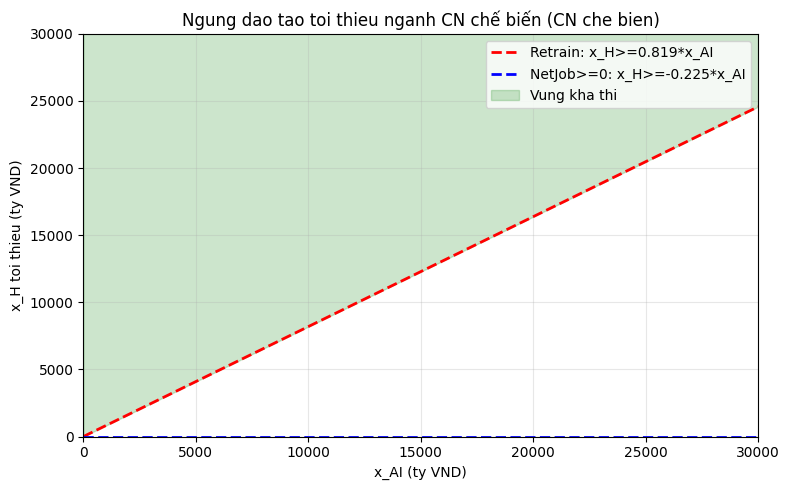

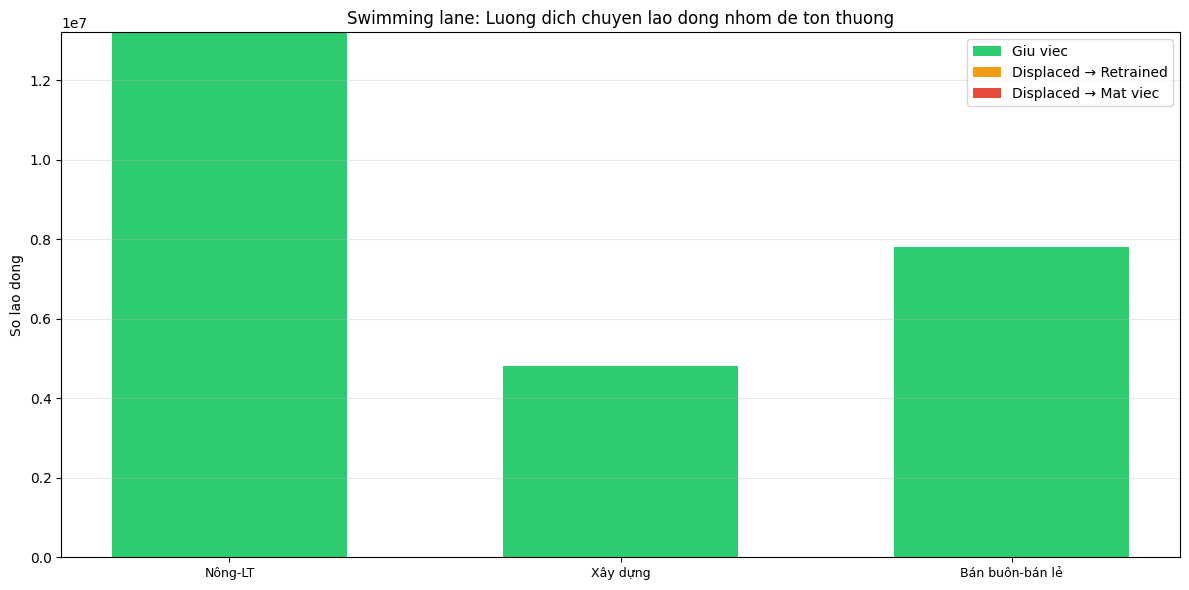

In [ ]:
import numpy as np
from scipy.optimize import linprog
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 9: Tac dong AI toi thi truong lao dong VN
# ============================================================

N = 8
sectors = ['Nông-LT', 'CN chế biến', 'Xây dựng', 'Bán buôn-bán lẻ',
           'Tài chính-NH', 'Logistics', 'CNTT-TT', 'Giáo dục-ĐT']

L = np.array([13.20, 11.50, 4.80, 7.80, 0.55, 1.95, 0.62, 2.15])
risk = np.array([18, 42, 25, 38, 52, 35, 28, 22]) / 100

a1 = np.array([8.5, 32.5, 12.8, 22.4, 45.8, 28.5, 62.5, 18.5])
b1_arr = np.array([45, 28, 35, 32, 22, 30, 20, 55])
c1 = np.array([5.2, 62.4, 18.5, 48.2, 72.5, 42.8, 32.5, 12.5])
d1 = np.array([50, 32, 42, 38, 26, 36, 24, 62])

# ============================================================
# Cau 9.4.1: LP toi da hoa tong NetJob
# ============================================================
print("="*60)
print("BÀI 9: Tác động AI tới thị trường lao động")
print("="*60)
print("\nCAU 9.4.1: LP toi da hoa tong NetJob")
print("="*60)

# Bien: [x_AI_0..x_AI_7, x_H_0..x_H_7] = 16 bien
# NetJob_i = NewJob_i + UpgradeJob_i - Displaced_i
#   NewJob = a1 * x_AI  (a2*x_D trong mo hinh ly thuyet, nhung bai toan chi phan bo x_AI va x_H)
#   Displaced = c1 * risk * x_AI
#   UpgradeJob = b1 * x_H  (nang cap ky nang -> giu viec, KHONG phai viec lam moi)
# LUU Y: a2 (he so xD) duoc dinh nghia trong du lieu nhung khong su dung do bai toan
# chi co 2 hang muc dau tu (x_AI, x_H). De mo rong, them bien x_D.
coeff_AI = a1 - c1 * risk
coeff_H = b1_arr.copy()

print("\nHe so hieu qua net (a1 - c1*risk) va he so upgrade (b1):")
print("  LUU Y: Rang buoc x_AI >= 9,000 ty (30% ngan sach) de tranh trivial solution")
for i in range(N):
    retrain_ratio = c1[i]*risk[i] / d1[i]
    print(f"  {sectors[i]:<15}: net_AI={coeff_AI[i]:>6.1f}, b1={b1_arr[i]:>3}, "
          f"c1*risk={c1[i]*risk[i]:>5.1f}, d1={d1[i]:>3}, retrain_ratio={retrain_ratio:.3f}")

c_obj = np.concatenate([-coeff_AI, -coeff_H])

# R1: sum(x_AI + x_H) <= 30000
A1 = np.concatenate([np.ones(N), np.ones(N)]).reshape(1, -1)

# R1b: x_AI floor - tranh trivial solution (x_AI=0, x_H=30000)
# Bat buoc it nhat 30% ngan sach cho AI de dam bao chuyen doi so thuc su
A1b = np.concatenate([-np.ones(N), np.zeros(N)]).reshape(1, -1)

# R2: NetJob_i >= 0
A2 = np.zeros((N, 2*N))
for i in range(N):
    A2[i, i] = -coeff_AI[i]
    A2[i, N+i] = -b1_arr[i]

# R3: Displaced <= RetrainCap: c1_i*risk_i*x_AI_i <= d1_i*x_H_i
A3 = np.zeros((N, 2*N))
for i in range(N):
    A3[i, i] = c1[i] * risk[i]
    A3[i, N+i] = -d1[i]

A_ub = np.vstack([A1, A1b, A2, A3])
b_ub = np.concatenate([[30000], [-9000], np.zeros(N), np.zeros(N)])
bounds = [(0, None)] * (2*N)

res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

x_AI_opt = res.x[:N]
x_H_opt = res.x[N:]
NetJob = coeff_AI * x_AI_opt + b1_arr * x_H_opt
NewJob = a1 * x_AI_opt
Upgrade = b1_arr * x_H_opt
Displaced = c1 * risk * x_AI_opt
RetrainCap = d1 * x_H_opt

print(f"\nTrang thai: {res.message}")
print(f"Tong NetJob = {-res.fun:,.0f} viec lam")
print(f"\n{'Nganh':<15} {'x_AI':>8} {'x_H':>8} {'NewJob':>8} {'Upgrade':>8} "
      f"{'Displace':>8} {'RetrCap':>8} {'NetJob':>8}")
print("-" * 88)
for i in range(N):
    print(f"{sectors[i]:<15} {x_AI_opt[i]:>8.0f} {x_H_opt[i]:>8.0f} {NewJob[i]:>8.0f} "
          f"{Upgrade[i]:>8.0f} {Displaced[i]:>8.0f} {RetrainCap[i]:>8.0f} {NetJob[i]:>8.0f}")
print("-" * 88)
print(f"{'Tong':<15} {x_AI_opt.sum():>8.0f} {x_H_opt.sum():>8.0f} {NewJob.sum():>8.0f} "
      f"{Upgrade.sum():>8.0f} {Displaced.sum():>8.0f} {RetrainCap.sum():>8.0f} {NetJob.sum():>8.0f}")
print(f"\nNgan sach su dung: {x_AI_opt.sum() + x_H_opt.sum():,.0f} / 30,000 ty VND")

# ============================================================
# Cau 9.4.2: Ngung dao tao toi thieu CN che bien
# ============================================================
print("\n" + "="*60)
print("CAU 9.4.2: Ngung dao tao toi thieu CN che bien")
print("="*60)

i = 1  # CN che bien
net_coeff = a1[i] - c1[i]*risk[i]
retrain_ratio = c1[i]*risk[i] / d1[i]
print(f"\nNganh CN che bien:")
print(f"  a1={a1[i]}, c1*risk={c1[i]*risk[i]:.1f}, d1={d1[i]}")
print(f"  He so net AI = {net_coeff:.1f} (DUONG -> AI tao net job)")
print(f"  Ty le retrain: c1*risk/d1 = {retrain_ratio:.3f}")
print(f"  => Rang buoc Displaced <= RetrainCap: {c1[i]*risk[i]:.1f}*x_AI <= {d1[i]}*x_H")
print(f"  => x_H >= {retrain_ratio:.3f} * x_AI")
print(f"  => Moi 1 ty dau tu AI can {retrain_ratio:.3f} ty dao tao de dam bao retraining capacity")
print(f"\n  Dac biet: neu x_AI toi da (dung het ngan sach):")
x_AI_max = 30000
x_H_needed = retrain_ratio * x_AI_max
print(f"    x_AI={x_AI_max} -> x_H >= {x_H_needed:.0f} (retrain constraint)")
print(f"    nhung NetJob >= 0 -> x_H >= {-net_coeff/b1_arr[i]:.3f}*x_AI = {-net_coeff/b1_arr[i]*x_AI_max:.0f}")
print(f"    => Rang buoc retrain BINDING hon NetJob: can x_H >= {x_H_needed:.0f}")

# Ve minh hoa
x_AI_range = np.linspace(0, 30000, 100)
x_H_retrain = retrain_ratio * x_AI_range
x_H_netjob = np.maximum(0, -net_coeff / b1_arr[i] * x_AI_range)
x_H_min = np.maximum(x_H_retrain, x_H_netjob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_AI_range, x_H_retrain, 'r--', linewidth=2, label=f'Retrain: x_H>={retrain_ratio:.3f}*x_AI')
ax.plot(x_AI_range, x_H_netjob, 'b--', linewidth=2, label=f'NetJob>=0: x_H>={-net_coeff/b1_arr[i]:.3f}*x_AI')
ax.fill_between(x_AI_range, x_H_min, 30000, alpha=0.2, color='green', label='Vung kha thi')
ax.set_xlabel('x_AI (ty VND)')
ax.set_ylabel('x_H toi thieu (ty VND)')
ax.set_title(f'Ngung dao tao toi thieu nganh {sectors[i]} (CN che bien)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 30000)
ax.set_ylim(0, 30000)
plt.tight_layout()
plt.savefig('bai9_retraining_threshold.png', dpi=150)

# ============================================================
# Cau 9.4.3: Mo phong nhom de ton thuong
# ============================================================
print("\n" + "="*60)
print("CAU 9.4.3: Mo phong nhom de ton thuong (nganh 1,3,4)")
print("="*60)

vulnerable = [0, 2, 3]  # Nong-LT, Xay dung, Ban buon
print(f"\nNhom de ton thuong: {[sectors[i] for i in vulnerable]}")
print(f"\n{'Nganh':<15} {'LĐ(tr)':>8} {'Risk%':>6} {'x_AI':>8} {'x_H':>8} "
      f"{'Displace':>8} {'NetJob':>8} {'NetJob/LĐ%':>10}")
print("-" * 75)
total_disp_vuln = 0
total_l_vuln = 0
for i in vulnerable:
    pct = NetJob[i] / (L[i]*1e6) * 100 if L[i] > 0 else 0
    print(f"{sectors[i]:<15} {L[i]:>8.2f} {risk[i]*100:>5.0f}% {x_AI_opt[i]:>8.0f} "
          f"{x_H_opt[i]:>8.0f} {Displaced[i]:>8.0f} {NetJob[i]:>8.0f} {pct:>9.2f}%")
    total_disp_vuln += Displaced[i]
    total_l_vuln += L[i]*1e6

print(f"\nTong lao dong de ton thuong: {total_l_vuln:,.0f}")
print(f"Tong displaced: {total_disp_vuln:,.0f}")
print(f"Ty le displaced/LĐ: {total_disp_vuln/total_l_vuln*100:.2f}%")

# Ve Sankey luong dich chuyen lao dong (matplotlib-based)
fig, ax = plt.subplots(figsize=(12, 6))

vuln_names = [sectors[i] for i in vulnerable]
y_pos = np.arange(len(vulnerable))

# Tinh luong
kept_arr = []; retrain_arr = []; lost_arr = []
for i in vulnerable:
    displaced = Displaced[i]
    retrain = min(displaced, RetrainCap[i])
    lost = max(0, displaced - retrain)
    kept_arr.append(L[i]*1e6 - displaced)
    retrain_arr.append(retrain)
    lost_arr.append(lost)

width = 0.6
# Stack bar: kept + retrain + lost
p1 = ax.bar(y_pos, kept_arr, width, label='Giu viec', color='#2ecc71')
p2 = ax.bar(y_pos, retrain_arr, width, bottom=kept_arr, label='Displaced → Retrained', color='#f39c12')
bottoms2 = [k+r for k,r in zip(kept_arr, retrain_arr)]
p3 = ax.bar(y_pos, lost_arr, width, bottom=bottoms2, label='Displaced → Mat viec', color='#e74c3c')

ax.set_xticks(y_pos)
ax.set_xticklabels(vuln_names, fontsize=9)
ax.set_ylabel('So lao dong')
ax.set_title('Swimming lane: Luong dich chuyen lao dong nhom de ton thuong')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Them text
for i in range(len(vulnerable)):
    idx = vulnerable[i]
    if Displaced[idx] > 0:
        ax.text(i, kept_arr[i]+retrain_arr[i]/2, f'Retrain:{retrain_arr[i]:.0f}',
                ha='center', va='center', fontsize=8, fontweight='bold')
        if lost_arr[i] > 0:
            ax.text(i, bottoms2[i]+lost_arr[i]/2, f'Lost:{lost_arr[i]:.0f}',
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('bai9_sankey.png', dpi=150)
print("Da luu bieu do swimming lane: bai9_sankey.png")

# ============================================================
# Cau 9.4.4: Rang buoc Displaced <= 5% L
# ============================================================
print("\n" + "="*60)
print("CAU 9.4.4: Them rang buoc Displaced <= 5% L")
print("="*60)

A4 = np.zeros((N, 2*N))
for i in range(N):
    A4[i, i] = c1[i] * risk[i]
b4 = 0.05 * L * 1e6

A_ub4 = np.vstack([A_ub, A4])
b_ub4 = np.concatenate([b_ub, b4])

res4 = linprog(c_obj, A_ub=A_ub4, b_ub=b_ub4, bounds=bounds, method='highs')

if res4.success:
    x_AI_4 = res4.x[:N]
    x_H_4 = res4.x[N:]
    NetJob4 = coeff_AI * x_AI_4 + b1_arr * x_H_4
    Displaced4 = c1 * risk * x_AI_4
    print(f"Tong NetJob (co rang buoc 5%) = {-res4.fun:,.0f}")
    print(f"Tong NetJob (khong rang buoc) = {-res.fun:,.0f}")
    diff = -res.fun - (-res4.fun)
    print(f"Giam: {diff:,.0f} viec lam ({diff/(-res.fun)*100:.1f}%)")
    print(f"\n{'Nganh':<15} {'Displace':>10} {'5% L':>10} {'Vi pham?':>10}")
    for i in range(N):
        disp = Displaced4[i]
        limit = 0.05 * L[i] * 1e6
        print(f"{sectors[i]:<15} {disp:>10.0f} {limit:>10.0f} {'CO' if disp > limit+1 else 'KHONG':>10}")
else:
    print(f"KHONG kha thi: {res4.message}")


## Bài 10 — Quy hoạch ngẫu nhiên 2 giai đoạn

*File gốc: `bai10_stochastic.py`*


BÀI 10: Quy hoạch ngẫu nhiên 2 giai đoạn (Pyomo)

CAU 10.5.1: Mo hinh SP
Z*_SP = 98,575.00

First-stage:
  x_I =          0
  x_D =          0
  x_AI =      65000
  x_H =          0
  Tong =      65000

Second-stage:
  s1 (p=0.3): y_I=0, y_D=15000, y_AI=-0, y_H=0 | tong=15000
  s2 (p=0.45): y_I=0, y_D=15000, y_AI=-0, y_H=0 | tong=15000
  s3 (p=0.2): y_I=0, y_D=0, y_AI=0, y_H=15000 | tong=15000
  s4 (p=0.05): y_I=0, y_D=0, y_AI=0, y_H=15000 | tong=15000

CAU 10.5.2: Giai xac dinh tung kich ban rieng le

s1: Z* = 101,500.00
  x: I=0, D=0, AI=65000, H=0
  y: I=0, D=15000, AI=-0, H=0

s2: Z* = 97,750.00
  x: I=0, D=0, AI=65000, H=0
  y: I=0, D=15000, AI=-0, H=0

s3: Z* = 96,250.00
  x: I=0, D=0, AI=65000, H=0
  y: I=0, D=0, AI=0, H=15000

s4: Z* = 97,750.00
  x: I=0, D=0, AI=65000, H=0
  y: I=0, D=0, AI=0, H=15000

EV first-stage: {'I': 0.0, 'D': 0.0, 'AI': 65000.0, 'H': 0.0}

CAU 10.5.3: VSS va EVPI
Z_SP  (Stochastic)  = 98,575.00
Z_EV  (EV solution) = 98,575.00
Z_WS  (Wait&See)    = 98,5

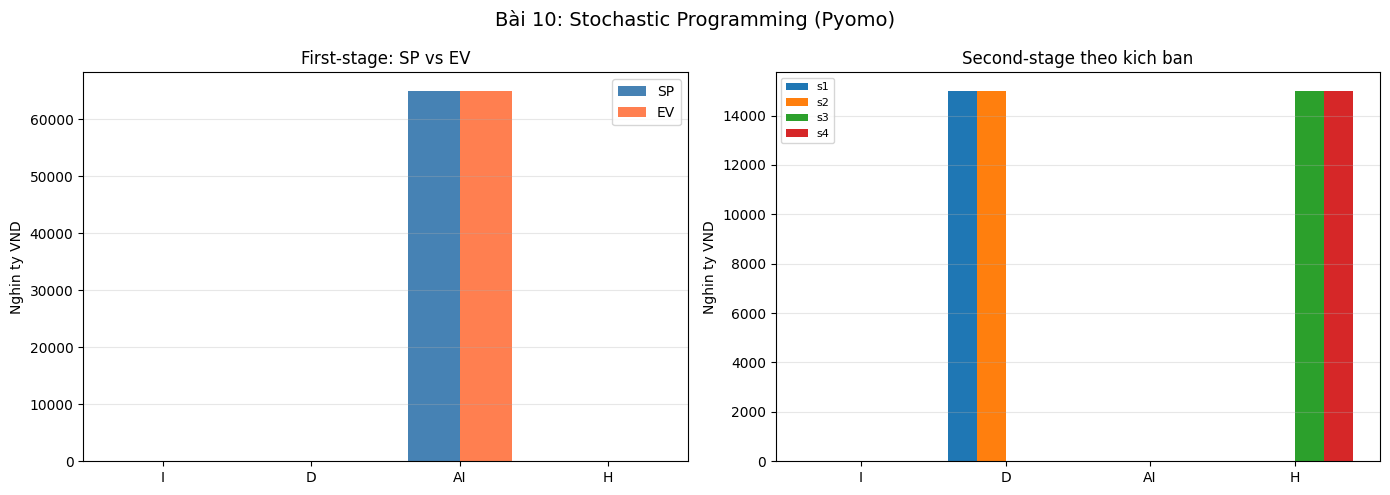

In [ ]:
import pyomo.environ as pyo
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 10: Quy hoach ngau nhien hai giai doan (Pyomo)
# ============================================================

J = ['I', 'D', 'AI', 'H']
S = ['s1', 's2', 's3', 's4']
p_s = {'s1': 0.30, 's2': 0.45, 's3': 0.20, 's4': 0.05}

beta_base = {'I': 1.00, 'D': 1.10, 'AI': 1.25, 'H': 0.95}
beta_s = {
    ('s1','I'):1.25,('s1','D'):1.35,('s1','AI'):1.55,('s1','H'):1.05,
    ('s2','I'):1.00,('s2','D'):1.10,('s2','AI'):1.25,('s2','H'):0.95,
    ('s3','I'):0.75,('s3','D'):0.85,('s3','AI'):0.90,('s3','H'):1.00,
    ('s4','I'):0.40,('s4','D'):0.50,('s4','AI'):0.55,('s4','H'):1.10
}


def build_model(include_second_stage=True, fixed_scenario=None, fixed_x=None):
    """
    Xay dung mo hinh Pyomo.

    Parameters
    ----------
    include_second_stage : bool - co giai doan 2 khong
    fixed_scenario : str or None - neu chi dinh, chi dung 1 kich ban
    fixed_x : dict or None - neu chi dinh, co dinh first-stage
    """
    m = pyo.ConcreteModel()
    m.J = pyo.Set(initialize=J)
    m.S = pyo.Set(initialize=S if fixed_scenario is None else [fixed_scenario])

    m.beta = pyo.Param(m.J, initialize=beta_base)
    beta_s_filtered = {(s,j): beta_s[s,j] for s in (S if fixed_scenario is None else [fixed_scenario]) for j in J}
    m.beta_s = pyo.Param(m.S, m.J, initialize=beta_s_filtered)
    m.p = pyo.Param(m.S, initialize=p_s if fixed_scenario is None else {fixed_scenario: 1.0})

    if fixed_x is None:
        m.x = pyo.Var(m.J, within=pyo.NonNegativeReals)
    else:
        m.x = pyo.Param(m.J, initialize=fixed_x)

    if include_second_stage:
        m.y = pyo.Var(m.S, m.J, within=pyo.NonNegativeReals)

    # Rang buoc first-stage
    if fixed_x is None:
        m.budget1 = pyo.Constraint(expr=sum(m.x[j] for j in m.J) <= 65000)

    if include_second_stage:
        def budget2_rule(m, s):
            return sum(m.y[s,j] for j in m.J) <= 15000
        m.budget2 = pyo.Constraint(m.S, rule=budget2_rule)

        def ai_cap_rule(m, s):
            return m.y[s,'AI'] <= 0.5 * (m.x['H'] if fixed_x is None else fixed_x['H'])
        m.ai_cap = pyo.Constraint(m.S, rule=ai_cap_rule)

    # Ham muc tieu
    # LUU Y: De bai de cap Penalty(y_s - reserve) nhung khong dinh nghia cong thuc cu the.
    # O day Penalty duoc mo hinh hoa gian tiep qua rang buoc ngan sach y_s <= 15000.
    # De mo rong, co the them: penalty_coeff * max(0, sum(y_s) - reserve)
    def obj_rule(m):
        first = sum(m.beta[j] * m.x[j] for j in m.J)
        if include_second_stage:
            second = sum(m.p[s] * sum(m.beta_s[s,j] * m.y[s,j] for j in m.J) for s in m.S)
            return first + second
        return first
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    return m


def solve(m):
    solver = pyo.SolverFactory('appsi_highs')
    if not solver.available():
        solver = pyo.SolverFactory('glpk')
    if not solver.available():
        solver = pyo.SolverFactory('cbc')
    result = solver.solve(m, tee=False)
    return result


def extract_solution(m, has_y=True):
    x_val = {j: pyo.value(m.x[j]) for j in J}
    y_val = {}
    if has_y:
        for s in list(m.S):
            y_val[s] = {j: pyo.value(m.y[s,j]) for j in J}
    return x_val, y_val, pyo.value(m.obj)


# ============================================================
# Cau 10.5.1: Mo hinh SP (Pyomo + GLPK)
# ============================================================
print("="*60)
print("BÀI 10: Quy hoạch ngẫu nhiên 2 giai đoạn (Pyomo)")
print("="*60)
print("\nCAU 10.5.1: Mo hinh SP")
print("="*60)

m_sp = build_model()
solve(m_sp)
x_sp, y_sp, Z_SP = extract_solution(m_sp)

print(f"Z*_SP = {Z_SP:,.2f}")
print(f"\nFirst-stage:")
for j in J:
    print(f"  x_{j} = {x_sp[j]:>10.0f}")
print(f"  Tong = {sum(x_sp.values()):>10.0f}")

print(f"\nSecond-stage:")
for s in S:
    total = sum(y_sp[s].values())
    print(f"  {s} (p={p_s[s]}): y_I={y_sp[s]['I']:.0f}, y_D={y_sp[s]['D']:.0f}, "
          f"y_AI={y_sp[s]['AI']:.0f}, y_H={y_sp[s]['H']:.0f} | tong={total:.0f}")

# ============================================================
# Cau 10.5.2: Giai xac dinh tung kich ban
# ============================================================
print("\n" + "="*60)
print("CAU 10.5.2: Giai xac dinh tung kich ban rieng le")
print("="*60)

det_results = {}
for s in S:
    m_det = build_model(fixed_scenario=s)
    solve(m_det)
    x_d, y_d, Z_d = extract_solution(m_det)
    det_results[s] = {'x': x_d, 'y': y_d, 'Z': Z_d}
    print(f"\n{s}: Z* = {Z_d:,.2f}")
    print(f"  x: " + ", ".join(f"{j}={x_d[j]:.0f}" for j in J))
    print(f"  y: " + ", ".join(f"{j}={y_d[s][j]:.0f}" for j in J))

# EV solution: dung beta trung binh (expected value scenario)
beta_avg = {j: sum(p_s[s]*beta_s[s,j] for s in S) for j in J}
# Xay dung model voi beta_avg cho ca 2 stages
m_ev = pyo.ConcreteModel()
m_ev.J = pyo.Set(initialize=J)
m_ev.x = pyo.Var(m_ev.J, within=pyo.NonNegativeReals)
m_ev.budget1 = pyo.Constraint(expr=sum(m_ev.x[j] for j in m_ev.J) <= 65000)
m_ev.obj = pyo.Objective(expr=sum(beta_avg[j]*m_ev.x[j] for j in m_ev.J), sense=pyo.maximize)
solve(m_ev)
x_ev = {j: pyo.value(m_ev.x[j]) for j in J}
print(f"\nEV first-stage: {x_ev}")

# Z_EV: dung x_ev, optimize y tung scenario
Z_EV = sum(beta_base[j]*x_ev[j] for j in J)
for s in S:
    m_temp = build_model(fixed_x=x_ev, fixed_scenario=s)
    solve(m_temp)
    _, y_temp, _ = extract_solution(m_temp, has_y=True)
    Z_EV += p_s[s] * sum(beta_s[s,j]*y_temp[s][j] for j in J)

# Z_WS: perfect info -> tung scenario rieng
Z_WS = sum(p_s[s] * det_results[s]['Z'] for s in S)

# ============================================================
# Cau 10.5.3: VSS va EVPI
# ============================================================
print("\n" + "="*60)
print("CAU 10.5.3: VSS va EVPI")
print("="*60)

VSS = Z_SP - Z_EV
EVPI = Z_WS - Z_SP

print(f"Z_SP  (Stochastic)  = {Z_SP:,.2f}")
print(f"Z_EV  (EV solution) = {Z_EV:,.2f}")
print(f"Z_WS  (Wait&See)    = {Z_WS:,.2f}")
print(f"VSS = Z_SP - Z_EV = {VSS:,.2f} ({VSS/Z_SP*100:.2f}%)")
print(f"EVPI = Z_WS - Z_SP = {EVPI:,.2f} ({EVPI/Z_SP*100:.2f}%)")

print(f"\nY nghia:")
print(f"  VSS > 0: xem xet bat dinh khi quyet dinh co gia tri {VSS:,.0f}")
print(f"  EVPI: gia tri thong tin hoan hao la {EVPI:,.0f}")

# ============================================================
# Cau 10.5.4: Robust optimization (minimax regret)
# ============================================================
print("\n" + "="*60)
print("CAU 10.5.4: Robust optimization (minimax regret)")
print("="*60)

# Z*[s] = optimal cho tung scenario (da tinh o tren)
# Tim x toi uu min max_s {Z*[s] - Z[x,s]}
# Dung Pyomo: min w s.t. Z*[s] - Z[x,s] <= w for all s

m_rob = pyo.ConcreteModel()
m_rob.J = pyo.Set(initialize=J)
m_rob.S = pyo.Set(initialize=S)
m_rob.x = pyo.Var(m_rob.J, within=pyo.NonNegativeReals)
m_rob.y = pyo.Var(m_rob.S, m_rob.J, within=pyo.NonNegativeReals)
m_rob.w = pyo.Var(within=pyo.Reals)  # max regret

beta_s_filtered = {(s,j): beta_s[s,j] for s in S for j in J}
m_rob.beta_s = pyo.Param(m_rob.S, m_rob.J, initialize=beta_s_filtered)
m_rob.beta = pyo.Param(m_rob.J, initialize=beta_base)
m_rob.p = pyo.Param(m_rob.S, initialize=p_s)
m_rob.Zstar = pyo.Param(m_rob.S, initialize={s: det_results[s]['Z'] for s in S})

m_rob.budget1 = pyo.Constraint(expr=sum(m_rob.x[j] for j in m_rob.J) <= 65000)
def budget2_rule(m, s):
    return sum(m.y[s,j] for j in m.J) <= 15000
m_rob.budget2 = pyo.Constraint(m_rob.S, rule=budget2_rule)
def ai_cap_rule(m, s):
    return m.y[s,'AI'] <= 0.5 * m.x['H']
m_rob.ai_cap = pyo.Constraint(m_rob.S, rule=ai_cap_rule)

# Regret constraints: Z*[s] - (beta*x + beta_s*y_s) <= w
def regret_rule(m, s):
    z_here = sum(m.beta[j]*m.x[j] for j in m.J) + sum(m.beta_s[s,j]*m.y[s,j] for j in m.J)
    return m.Zstar[s] - z_here <= m.w
m_rob.regret = pyo.Constraint(m_rob.S, rule=regret_rule)

m_rob.obj = pyo.Objective(expr=m_rob.w, sense=pyo.minimize)
solve(m_rob)

x_rob = {j: pyo.value(m_rob.x[j]) for j in J}
w_rob = pyo.value(m_rob.w)
print(f"Robust first-stage: {x_rob}")
print(f"Minimax regret = {w_rob:.0f}")

# So sanh regret cua SP, EV, Robust
def compute_regret_dict(x_fixed):
    reg = {}
    for s in S:
        z_here = sum(beta_base[j]*x_fixed[j] for j in J)
        m_temp = build_model(fixed_x=x_fixed, fixed_scenario=s)
        solve(m_temp)
        _, y_t, _ = extract_solution(m_temp, has_y=True)
        z_here += sum(beta_s[s,j]*y_t[s][j] for j in J)
        reg[s] = det_results[s]['Z'] - z_here
    return reg

reg_sp = compute_regret_dict(x_sp)
reg_ev = compute_regret_dict(x_ev)
reg_rob = compute_regret_dict(x_rob)

print(f"\n{'Kich ban':<8} {'Z*[s]':>10} {'Reg_SP':>8} {'Reg_EV':>8} {'Reg_Rob':>8}")
for s in S:
    print(f"{s:<8} {det_results[s]['Z']:>10.0f} {reg_sp[s]:>8.0f} {reg_ev[s]:>8.0f} {reg_rob[s]:>8.0f}")
print(f"{'Max':<8} {'':>10} {max(reg_sp.values()):>8.0f} {max(reg_ev.values()):>8.0f} {max(reg_rob.values()):>8.0f}")

# ============================================================
# Ve do thi so sanh
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(J))
width = 0.35
sp_vals = [x_sp[j] for j in J]
ev_vals = [x_ev[j] for j in J]
ax.bar(x_pos-width/2, sp_vals, width, label='SP', color='steelblue')
ax.bar(x_pos+width/2, ev_vals, width, label='EV', color='coral')
ax.set_xticks(x_pos); ax.set_xticklabels(J)
ax.set_ylabel('Nghin ty VND'); ax.set_title('First-stage: SP vs EV'); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
for s_idx, s in enumerate(S):
    y_vals = [y_sp[s][j] for j in J]
    ax.bar(x_pos+s_idx*0.2-0.3, y_vals, 0.2, label=s)
ax.set_xticks(x_pos); ax.set_xticklabels(J)
ax.set_ylabel('Nghin ty VND'); ax.set_title('Second-stage theo kich ban'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Bài 10: Stochastic Programming (Pyomo)', fontsize=14)
plt.tight_layout(); plt.savefig('bai10_stochastic.png', dpi=150)


## Bài 11 — Q-learning chính sách kinh tế

*File gốc: `bai11_qlearning.py`*


BÀI 11: Q-learning cho chính sách kinh tế

CAU 11.3.3: Chính sách π*(s) = argmax Q(s,a)

Chinh sach toi uu cho 5 trang thai khoi dau:
  VN 2026 thuc te (GDP_med, D_med, AI_low, H_med)
    -> π* = So hoa nhanh (action 2)
    Q-values: Truyen thong=2.095, Can bang=2.418, So hoa nhanh=2.536, AI dan dat=2.524, Bao trum=2.342
  Kich ban te (GDP_low, D_low, AI_low, H_high)
    -> π* = So hoa nhanh (action 2)
    Q-values: Truyen thong=1.241, Can bang=2.352, So hoa nhanh=2.898, AI dan dat=1.988, Bao trum=2.428
  Kich ban tot (GDP_high, D_high, AI_high, H_high)
    -> π* = Bao trum (action 4)
    Q-values: Truyen thong=2.124, Can bang=2.497, So hoa nhanh=2.002, AI dan dat=1.057, Bao trum=3.021
  Sau khung hoang (GDP_low, D_med, AI_low, H_low)
    -> π* = AI dan dat (action 3)
    Q-values: Truyen thong=2.030, Can bang=2.225, So hoa nhanh=2.232, AI dan dat=2.305, Bao trum=2.164
  AI manh, D yeu (GDP_med, D_low, AI_high, H_med)
    -> π* = Can bang (action 1)
    Q-values: Truyen thong=1.222, Ca

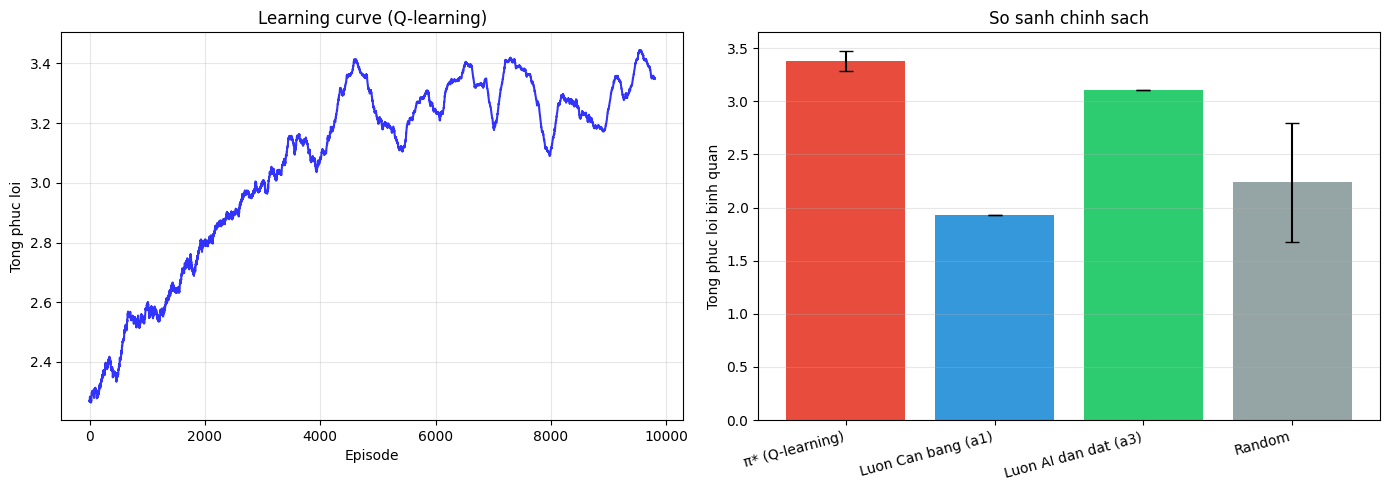

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# BAI 11: Q-learning cho chinh sach kinh te thich nghi
# ============================================================

class VietnamEconomyEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(5)
        # State: [gdp_level, d_level, ai_level, h_level]
        # LUU Y: Khong dung U (that nghiep) trong state vi action anh huong H truc tiep,
        # nhung state phai co H de agent hoc quan he action -> H -> Y -> reward.
        self.observation_space = spaces.MultiDiscrete([3, 3, 3, 3])
        self.T = 10

        self.allocation = {
            0: np.array([0.70, 0.10, 0.10, 0.10]),  # Truyen thong
            1: np.array([0.40, 0.25, 0.15, 0.20]),  # Can bang
            2: np.array([0.25, 0.45, 0.15, 0.15]),  # So hoa nhanh
            3: np.array([0.20, 0.20, 0.45, 0.15]),  # AI dan dat
            4: np.array([0.30, 0.20, 0.10, 0.40]),  # Bao trum
        }
        self.action_names = ['Truyen thong', 'Can bang', 'So hoa nhanh', 'AI dan dat', 'Bao trum']
        self.w = np.array([0.40, 0.25, 0.20, 0.15])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options and 'state' in options:
            self.state = np.array(options['state'])
        else:
            self.state = self.np_random.integers(0, 3, size=4)
        self.t = 0
        self.K = 27500.0
        self.D = 20.3
        self.AI = 86.0
        self.H = 30.0
        self.Y_prev = 12847.6
        return self.state.copy(), {}

    def step(self, action):
        a = self.allocation[action]
        budget = 2100.0  # ~15% GDP nam 2026

        dK = a[0] * budget
        dD = a[1] * budget * 0.01
        dAI = a[2] * budget * 0.05
        dH = a[3] * budget * 0.01

        self.K = (1 - 0.05)*self.K + dK
        self.D = (1 - 0.12)*self.D + dD
        self.AI = (1 - 0.15)*self.AI + dAI
        self.H = self.H + 0.8*dH - 0.02*self.H

        A = 33.70 * (1 + 0.003*(self.D/100) + 0.002*(self.AI/100) + 0.004*(self.H/100))**self.t
        L = 53.9 * 1.009**self.t
        Y = A * self.K**0.33 * L**0.42 * self.D**0.10 * self.AI**0.08 * self.H**0.07

        delta_gdp = (Y - self.Y_prev) / self.Y_prev
        delta_unemploy = max(0, -delta_gdp * 0.5)  # proxy: GDP giam -> that nghiep tang
        cyber_risk = (self.AI / (self.H + 1)) * 0.01  # AI cao, H thap -> rui ro an ninh
        emission = (self.K + self.AI) * 0.0001  # phat thai tu K va AI

        # Reward = w1*dGDP - w2*dUnemploy - w3*CyberRisk - w4*Emission
        # LUU Y: delta_unemploy, cyber_risk, emission la proxy don gian,
        # khong phai mo hinh kinh te chinh thuc.
        reward = (self.w[0] * delta_gdp * 100
                  - self.w[1] * delta_unemploy * 100
                  - self.w[2] * cyber_risk
                  - self.w[3] * emission)

        self.Y_prev = Y
        self.t += 1

        # State discretization thresholds:
        # GDP growth: <3%=low, 3-6%=med, >6%=high
        # D (% GDP): <25=low, 25-35=med, >35=high
        # AI (nghin DN): <100=low, 100-200=med, >200=high
        # H (% LĐ): <35=low, 35-50=med, >50=high
        gdp_level = 0 if delta_gdp < 0.03 else (1 if delta_gdp < 0.06 else 2)
        d_level = 0 if self.D < 25 else (1 if self.D < 35 else 2)
        ai_level = 0 if self.AI < 100 else (1 if self.AI < 200 else 2)
        h_level = 0 if self.H < 35 else (1 if self.H < 50 else 2)
        self.state = np.array([gdp_level, d_level, ai_level, h_level])

        done = self.t >= self.T
        return self.state.copy(), reward, done, False, {}

# ============================================================
# Q-learning Training
# ============================================================
print("="*60)
print("BÀI 11: Q-learning cho chính sách kinh tế")
print("="*60)

Q = np.zeros((3, 3, 3, 3, 5))
n_episodes = 10000
gamma = 0.95
alpha = 0.1
reward_history = []

env = VietnamEconomyEnv()

for ep in range(n_episodes):
    s, _ = env.reset()
    total_reward = 0
    eps = max(0.05, 1.0 - ep / 5000)

    while True:
        if np.random.rand() < eps:
            a = env.action_space.sample()
        else:
            a = int(np.argmax(Q[tuple(s)]))

        s2, r, done, _, _ = env.step(a)
        best_next = np.max(Q[tuple(s2)])
        Q[tuple(s) + (a,)] += alpha * (r + gamma * best_next * (1 - done) - Q[tuple(s) + (a,)])
        total_reward += r
        s = s2
        if done:
            break

    reward_history.append(total_reward)

# ============================================================
# Cau 11.3.3: Chinh sach pi*
# ============================================================
print("\n" + "="*60)
print("CAU 11.3.3: Chính sách π*(s) = argmax Q(s,a)")
print("="*60)

print("\nChinh sach toi uu cho 5 trang thai khoi dau:")
test_states = [
    ([1, 1, 0, 1], "VN 2026 thuc te (GDP_med, D_med, AI_low, H_med)"),
    ([0, 0, 0, 2], "Kich ban te (GDP_low, D_low, AI_low, H_high)"),
    ([2, 2, 2, 2], "Kich ban tot (GDP_high, D_high, AI_high, H_high)"),
    ([0, 1, 0, 0], "Sau khung hoang (GDP_low, D_med, AI_low, H_low)"),
    ([1, 0, 2, 1], "AI manh, D yeu (GDP_med, D_low, AI_high, H_med)"),
]

for state, desc in test_states:
    a = int(np.argmax(Q[tuple(state)]))
    q_vals = Q[tuple(state)]
    print(f"  {desc}")
    print(f"    -> π* = {env.action_names[a]} (action {a})")
    print(f"    Q-values: {', '.join(f'{env.action_names[i]}={q_vals[i]:.3f}' for i in range(5))}")

# ============================================================
# Cau 11.3.4: So sanh voi chinh sach rule-based
# ============================================================
print("\n" + "="*60)
print("CAU 11.3.4: So sanh voi rule-based")
print("="*60)

def evaluate_policy(policy_fn, n_eval=500):
    rewards = []
    for _ in range(n_eval):
        s, _ = env.reset()
        total = 0
        while True:
            a = policy_fn(s)
            s, r, done, _, _ = env.step(a)
            total += r
            if done:
                break
        rewards.append(total)
    return np.mean(rewards), np.std(rewards)

def policy_optimal(s): return int(np.argmax(Q[tuple(s)]))
def policy_always1(s): return 1  # Can bang
def policy_always3(s): return 3  # AI dan dat
def policy_random(s): return np.random.randint(5)

policies = [
    ('π* (Q-learning)', policy_optimal),
    ('Luon Can bang (a1)', policy_always1),
    ('Luon AI dan dat (a3)', policy_always3),
    ('Random', policy_random),
]

print(f"\n{'Chinh sach':<25} {'Mean reward':>12} {'Std':>8}")
print("-" * 48)
results = {}
for name, fn in policies:
    mean_r, std_r = evaluate_policy(fn)
    results[name] = (mean_r, std_r)
    print(f"{name:<25} {mean_r:>12.2f} {std_r:>8.2f}")

# Learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
window = 200
smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
ax.plot(smoothed, 'b-', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Tong phuc loi')
ax.set_title('Learning curve (Q-learning)')
ax.grid(True, alpha=0.3)

ax = axes[1]
names = [p[0] for p in policies]
means = [results[n][0] for n in names]
stds = [results[n][1] for n in names]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
bars = ax.bar(range(len(names)), means, yerr=stds, color=colors, capsize=5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Tong phuc loi binh quan')
ax.set_title('So sanh chinh sach')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bai11_qlearning.png', dpi=150)

print(f"\nπ* hon Random: {results['π* (Q-learning)'][0] - results['Random'][0]:.2f}")
print(f"π* hon Luon Can bang: {results['π* (Q-learning)'][0] - results['Luon Can bang (a1)'][0]:.2f}")


## Bài 12 — AIDEOM-VN nguyên mẫu tích hợp

*File gốc: `bai12_aideom.py`*


BÀI 12: AIDEOM-VN - Nguyên mẫu tích hợp 6 module

M1: Du bao kinh te Cobb-Douglas 2026-2030
Kich ban                  2026    2027    2028    2029    2030
--------------------------------------------------------------
S1_Truyen thong          12847   13168   13478   13777   14066
S2_So hoa nhanh          12847   13627   14193   14645   15026
S3_AI dan dat            12847   13659   14240   14705   15102
S4_Bao trum              12847   13351   13770   14134   14459
S5_Toi uu                12847   13606   14197   14686   15108

M2: TOPSIS + Entropy weight

Trong so Entropy: {'grdp_per': np.float64(0.0787), 'fdi_regi': np.float64(0.4151), 'digital_': np.float64(0.0597), 'ai_readi': np.float64(0.139), 'trained_': np.float64(0.0628), 'rd_inten': np.float64(0.2361), 'internet': np.float64(0.0073), 'gini_coe': np.float64(0.0012)}

Vung                            C*_expert C*_entropy Rank_E Rank_En
Northern Midlands and Mountains     0.0993     0.1248
Red River Delta                    0.898

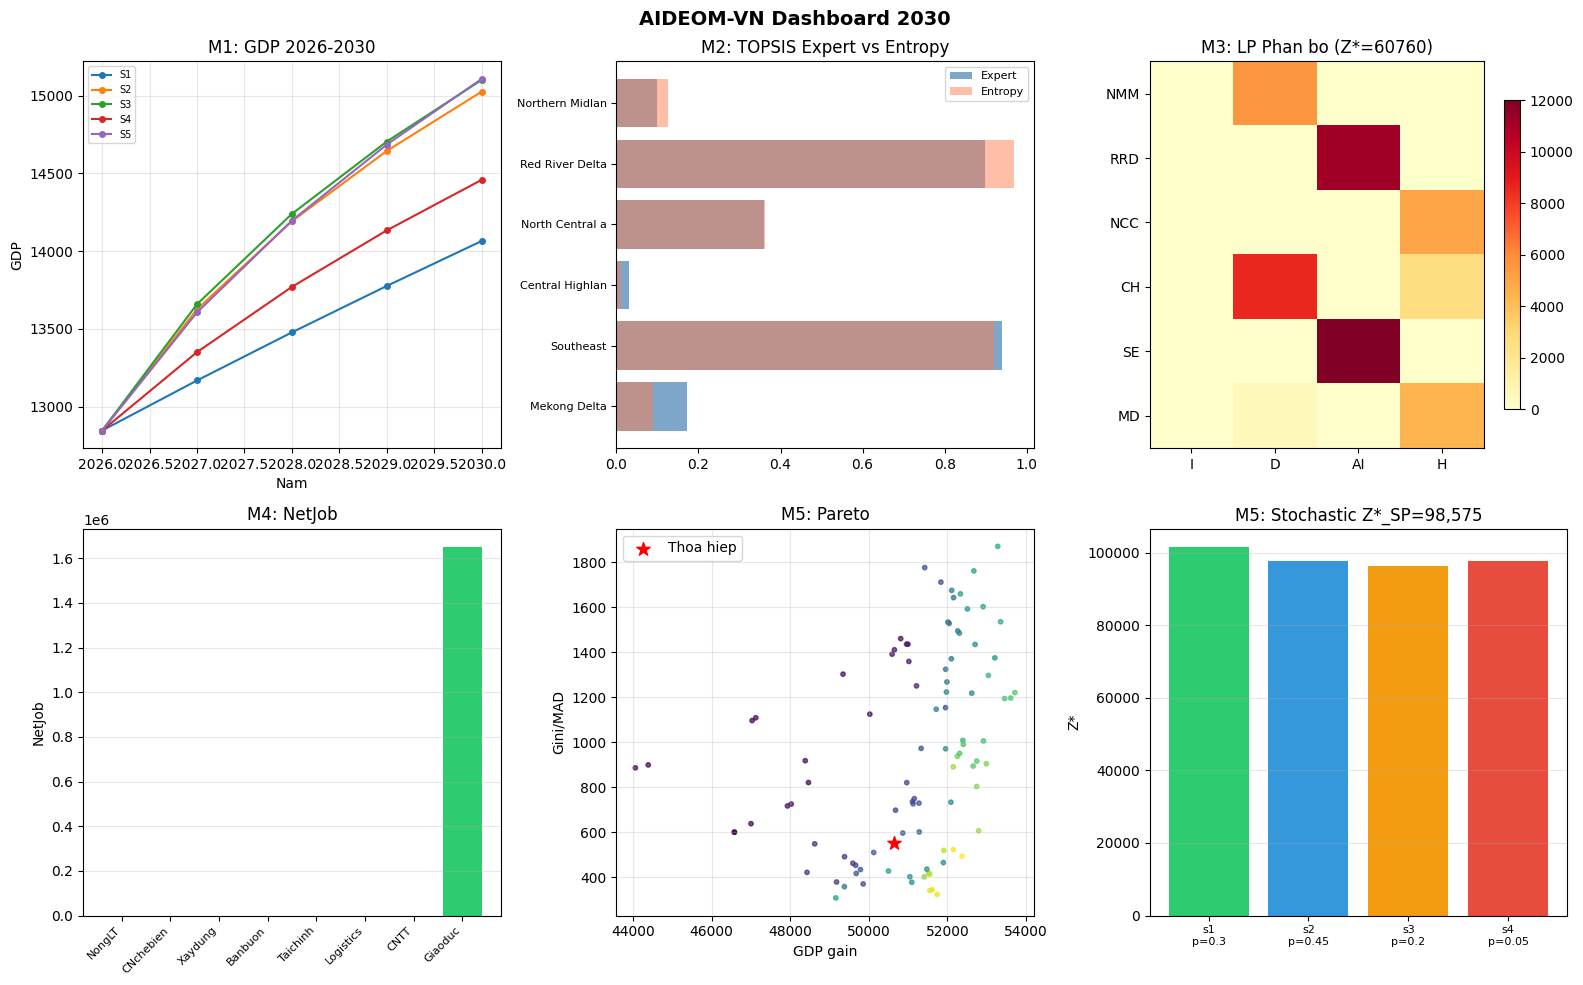

In [ ]:
"""AIDEOM-VN: Nguyen mau tich hop 6 module."""
import numpy as np
import pandas as pd
import pulp
from scipy.optimize import linprog, minimize
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize as moo_minimize
from pymoo.termination import get_termination
import matplotlib
import matplotlib.pyplot as plt

print("="*60)
print("BÀI 12: AIDEOM-VN - Nguyên mẫu tích hợp 6 module")
print("="*60)

# ============================================================
# M1: Du bao kinh te (Cobb-Douglas) 2026-2030
# ============================================================
print("\n" + "="*60)
print("M1: Du bao kinh te Cobb-Douglas 2026-2030")
print("="*60)

a, b, g, d, th = 0.33, 0.42, 0.10, 0.08, 0.07
K0, L0, D0_v, AI0, H0, A0 = 27500, 53.9, 20.3, 86, 30, 33.70
T = 4; years = list(range(2026, 2026+T+1)); budget_annual = 3000

def forecast(K0, D0, AI0, H0, A0, L0, alloc, T=T):
    K,D,AI,H,A = K0,D0,AI0,H0,A0
    traj = [A*K**a*L0**b*D**g*AI**d*H**th]
    for t in range(T):
        K=(1-0.05)*K+alloc['K']*budget_annual
        D=(1-0.12)*D+alloc['D']*budget_annual*0.01
        AI=(1-0.15)*AI+alloc['AI']*budget_annual*0.05
        H=H+0.8*alloc['H']*budget_annual*0.01-0.02*H
        A=A*(1+0.003*(D/100)+0.002*(AI/100)+0.004*(H/100))
        L=L0*1.009**(t+1)
        traj.append(A*K**a*L**b*D**g*AI**d*H**th)
    return traj

scenarios = {
    'S1_Truyen thong': {'K':0.70,'D':0.10,'AI':0.10,'H':0.10},
    'S2_So hoa nhanh': {'K':0.25,'D':0.45,'AI':0.15,'H':0.15},
    'S3_AI dan dat':   {'K':0.20,'D':0.20,'AI':0.45,'H':0.15},
    'S4_Bao trum':     {'K':0.30,'D':0.20,'AI':0.10,'H':0.40},
    'S5_Toi uu':       {'K':0.25,'D':0.25,'AI':0.30,'H':0.20},
}
gdp_fc = {n: forecast(K0,D0_v,AI0,H0,A0,L0,al) for n,al in scenarios.items()}

header = f"{'Kich ban':<22}" + "".join(f"{y:>8}" for y in years)
print(header); print("-"*62)
for name, traj in gdp_fc.items():
    print(f"{name:<22}" + "".join(f"{v:>8.0f}" for v in traj))

# ============================================================
# M2: TOPSIS + Entropy
# ============================================================
print("\n" + "="*60)
print("M2: TOPSIS + Entropy weight")
print("="*60)

df_reg = pd.read_csv('vietnam_regions_2024.csv')
criteria = ['grdp_per_capita_million_VND','fdi_registered_billion_USD',
            'digital_index_0_100','ai_readiness_0_100',
            'trained_labor_pct','rd_intensity_pct',
            'internet_penetration_pct','gini_coef']
is_ben = [True,True,True,True,True,True,True,False]
w_expert = np.array([0.10,0.10,0.15,0.20,0.15,0.15,0.05,0.10])

def topsis(X, w, is_ben):
    R = X/np.sqrt((X**2).sum(0)); V = R*w
    A_s = np.where(is_ben,V.max(0),V.min(0))
    A_n = np.where(is_ben,V.min(0),V.max(0))
    S_s = np.sqrt(((V-A_s)**2).sum(1))
    S_n = np.sqrt(((V-A_n)**2).sum(1))
    return S_n/(S_s+S_n)

def entropy_weights(X):
    P = X/X.sum(0); k = 1.0/np.log(len(X))
    E = -k*np.nansum(P*np.log(P+1e-12),0); d = 1-E
    return d/d.sum()

X = df_reg[criteria].values.astype(float)

# Expert weights
C_exp = topsis(X, w_expert, is_ben)
# Entropy weights
w_ent = entropy_weights(X)
C_ent = topsis(X, w_ent, is_ben)

print(f"\nTrong so Entropy: {dict(zip([c[:8] for c in criteria], np.round(w_ent,4)))}")
print(f"\n{'Vung':<30} {'C*_expert':>10} {'C*_entropy':>10} {'Rank_E':>6} {'Rank_En':>6}")
for i, rn in enumerate(df_reg['region_name_en']):
    re = np.argsort(-C_exp)[i] if False else None
    print(f"{rn:<30} {C_exp[i]:>10.4f} {C_ent[i]:>10.4f}")

rank_exp = np.argsort(-C_exp) + 1
rank_ent = np.argsort(-C_ent) + 1
for i, rn in enumerate(df_reg['region_name_en']):
    print(f"{rn:<30} {C_exp[i]:>10.4f} {C_ent[i]:>10.4f} {list(np.argsort(-C_exp)).index(i)+1:>6} {list(np.argsort(-C_ent)).index(i)+1:>6}")

# ============================================================
# M3: Phan bo ngan sach LP + Dynamic (Bai 8)
# ============================================================
print("\n" + "="*60)
print("M3: Phan bo LP (C1-C5) + Dynamic optimization")
print("="*60)

regions = ['NMM','RRD','NCC','CH','SE','MD']
items = ['I','D','AI','H']
beta = {('NMM','I'):1.15,('NMM','D'):0.85,('NMM','AI'):0.55,('NMM','H'):1.30,
        ('RRD','I'):0.95,('RRD','D'):1.25,('RRD','AI'):1.40,('RRD','H'):1.05,
        ('NCC','I'):1.05,('NCC','D'):0.95,('NCC','AI'):0.85,('NCC','H'):1.15,
        ('CH','I'):1.20,('CH','D'):0.75,('CH','AI'):0.45,('CH','H'):1.35,
        ('SE','I'):0.90,('SE','D'):1.30,('SE','AI'):1.55,('SE','H'):1.00,
        ('MD','I'):1.10,('MD','D'):0.85,('MD','AI'):0.65,('MD','H'):1.25}

D0_dict = dict(zip(
    df_reg['region_name_en'].map({'Northern Midlands and Mountains':'NMM',
        'Red River Delta':'RRD','North Central and South Central Coast':'NCC',
        'Central Highlands':'CH','Southeast':'SE','Mekong Delta':'MD'}),
    df_reg['digital_index_0_100']))

gamma_val, lam_val = 0.002, 0.6
m = pulp.LpProblem('M3',pulp.LpMaximize)
x = pulp.LpVariable.dicts('x',(regions,items),lowBound=0)
m += pulp.lpSum(beta[(r,j)]*x[r][j] for r in regions for j in items)
m += pulp.lpSum(x[r][j] for r in regions for j in items) <= 50000
for r in regions:
    m += pulp.lpSum(x[r][j] for j in items) >= 5000
    m += pulp.lpSum(x[r][j] for j in items) <= 12000
m += pulp.lpSum(x[r]['H'] for r in regions) >= 12000
Mvar = pulp.LpVariable('Dmax')
for r in regions:
    m += D0_dict[r]+gamma_val*x[r]['D'] <= Mvar
    m += D0_dict[r]+gamma_val*x[r]['D'] >= lam_val*Mvar
m.solve(pulp.PULP_CBC_CMD(msg=False))

alloc_mat = np.zeros((6,4))
for i,r in enumerate(regions):
    for j_idx,j in enumerate(items):
        alloc_mat[i,j_idx] = x[r][j].value()
Z_lp = pulp.value(m.objective)
print(f"LP Z* = {Z_lp:.0f} ty VND (co C5)")

# Dynamic: tinh TFP growth tu allocation (dung gia tri chi so, khong phai tien dau tu)
# D, AI, H la chi so, dau tu tang chung theo ty le rieng
# D_total (ty VND) -> chi so D tang = D_total * 0.01 / 50000 * 50  (scale)
# Don gian hon: tinh % ngan sach cho tung loai va uoc tinh TFP boost
total_budget = alloc_mat.sum()
pct_D = alloc_mat[:,1].sum() / total_budget  # ty le D
pct_AI = alloc_mat[:,2].sum() / total_budget  # ty le AI
pct_H = alloc_mat[:,3].sum() / total_budget   # ty le H
# TFP boost = phi * delta_index, voi delta_index ~ pct * budget * scale
# Dung scale tu Bai 8: D ~ 20% GDP, tang ~1% GDP/nam voi 25% ngan sach cho D
dD = pct_D * 50000 * 0.01   # ~ delta D (% GDP)
dAI = pct_AI * 50000 * 0.05  # ~ delta AI (nghin DN)
dH = pct_H * 50000 * 0.01    # ~ delta H (%)
tfp_boost = 0.003*(dD/100) + 0.002*(dAI/100) + 0.004*(dH/100)
print(f"Dynamic TFP boost uoc tinh: {tfp_boost*100:.3f}%/nam")
print(f"  dD={dD:.1f}% GDP, dAI={dAI:.0f} nghin DN, dH={dH:.1f}%")

# ============================================================
# M4: Thi truong lao dong NetJob
# ============================================================
print("\n" + "="*60)
print("M4: Mo phong thi truong lao dong")
print("="*60)

a1 = np.array([8.5,32.5,12.8,22.4,45.8,28.5,62.5,18.5])
b1 = np.array([45,28,35,32,22,30,20,55])
c1 = np.array([5.2,62.4,18.5,48.2,72.5,42.8,32.5,12.5])
d1 = np.array([50,32,42,38,26,36,24,62])
risk = np.array([18,42,25,38,52,35,28,22])/100
sec = ['NongLT','CNchebien','Xaydung','Banbuon','Taichinh','Logistics','CNTT','Giaoduc']
N = 8; coeff = a1-c1*risk

c_obj = np.concatenate([-coeff,-b1])
A1_l = np.concatenate([np.ones(N),np.ones(N)]).reshape(1,-1)
A2 = np.zeros((N,2*N))
for i in range(N): A2[i,i]=-coeff[i]; A2[i,N+i]=-b1[i]
A3 = np.zeros((N,2*N))
for i in range(N): A3[i,i]=c1[i]*risk[i]; A3[i,N+i]=-d1[i]
res = linprog(c_obj,A_ub=np.vstack([A1_l,A2,A3]),
              b_ub=np.concatenate([[30000],np.zeros(N),np.zeros(N)]),
              bounds=[(0,None)]*(2*N),method='highs')
xA=res.x[:N]; xH=res.x[N:]
NJ=coeff*xA+b1*xH
print(f"Tong NetJob = {-res.fun:,.0f}")
for i in range(N):
    if NJ[i]>1: print(f"  {sec[i]:<12}: x_AI={xA[i]:>6.0f}, x_H={xH[i]:>6.0f}, NetJob={NJ[i]:>8.0f}")

# ============================================================
# M5: NSGA-II da muc tieu + Stochastic
# ============================================================
print("\n" + "="*60)
print("M5: NSGA-II da muc tieu + Stochastic")
print("="*60)

# NSGA-II (gom tat 4 muc tieu tu Bai 7)
e_r = np.array([0.42,0.55,0.48,0.32,0.62,0.38])
rho_r = np.array([0.18,0.45,0.28,0.12,0.52,0.22])
sig_r = np.array([0.32,0.28,0.30,0.35,0.25,0.30])
beta_mat = np.array([[beta[(r,j)] for j in items] for r in regions])
D0_arr = np.array([D0_dict[r] for r in regions])

class M5Problem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=24, n_obj=4, n_ieq_constr=20,
                         xl=np.zeros(24), xu=np.ones(24)*12000)
    def _evaluate(self, x, out, *args, **kwargs):
        X = x.reshape(6,4)
        f1 = -(beta_mat*X).sum()
        sums = X.sum(1); f2 = np.abs(sums-sums.mean()).mean()
        f3 = (e_r*(X[:,0]+X[:,2])).sum()
        f4 = (rho_r*X[:,2]).sum()-(sig_r*X[:,3]).sum()
        out['F'] = [f1,f2,f3,f4]
        g = [X.sum()-50000]
        for r in range(6): g.append(5000-X[r].sum())
        for r in range(6): g.append(X[r].sum()-12000)
        g.append(12000-X[:,3].sum())
        D_new = D0_arr+gamma_val*X[:,1]; D_max = D_new.max()
        for r in range(6): g.append(lam_val*D_max-D_new[r])
        out['G'] = np.array(g)

res_nsga = moo_minimize(M5Problem(), NSGA2(pop_size=100),
                         get_termination("n_gen",200), seed=42, verbose=False)
F = res_nsga.F
print(f"Pareto: {len(F)} nghiem")
print(f"  f1 GDP gain: [{-F[:,0].max():.0f}, {-F[:,0].min():.0f}]")
print(f"  f2 Gini/MAD: [{F[:,1].min():.1f}, {F[:,1].max():.1f}]")

# TOPSIS tren Pareto -> chon thoa hiep
w_policy = np.array([0.40,0.25,0.20,0.15])
R_p = F/np.sqrt((F**2).sum(0)); V_p = R_p*w_policy
A_s_p = V_p.min(0); A_n_p = V_p.max(0)
S_s_p = np.sqrt(((V_p-A_s_p)**2).sum(1))
S_n_p = np.sqrt(((V_p-A_n_p)**2).sum(1))
C_s_p = S_n_p/(S_s_p+S_n_p)
best = np.argmax(C_s_p)
print(f"  Thoa hiep: GDP={-F[best,0]:.0f}, Gini={F[best,1]:.1f}, C*={C_s_p[best]:.4f}")

# Stochastic (goi Pyomo tu Bai 10)
print("\n  Stochastic (Pyomo):")
try:
    import pyomo.environ as pyo
    J_s = ['I','D','AI','H']; S_s = ['s1','s2','s3','s4']
    beta_base_s = {'I':1.00,'D':1.10,'AI':1.25,'H':0.95}
    beta_s_dict = {('s1','I'):1.25,('s1','D'):1.35,('s1','AI'):1.55,('s1','H'):1.05,
                   ('s2','I'):1.00,('s2','D'):1.10,('s2','AI'):1.25,('s2','H'):0.95,
                   ('s3','I'):0.75,('s3','D'):0.85,('s3','AI'):0.90,('s3','H'):1.00,
                   ('s4','I'):0.40,('s4','D'):0.50,('s4','AI'):0.55,('s4','H'):1.10}
    p_s_dict = {'s1':0.30,'s2':0.45,'s3':0.20,'s4':0.05}
    m_sp = pyo.ConcreteModel()
    m_sp.J = pyo.Set(initialize=J_s); m_sp.S = pyo.Set(initialize=S_s)
    m_sp.x = pyo.Var(m_sp.J, within=pyo.NonNegativeReals)
    m_sp.y = pyo.Var(m_sp.S, m_sp.J, within=pyo.NonNegativeReals)
    m_sp.beta = pyo.Param(m_sp.J, initialize=beta_base_s)
    m_sp.beta_s = pyo.Param(m_sp.S, m_sp.J, initialize=beta_s_dict)
    m_sp.p = pyo.Param(m_sp.S, initialize=p_s_dict)
    m_sp.budget1 = pyo.Constraint(expr=sum(m_sp.x[j] for j in m_sp.J) <= 65000)
    def b2(m,s): return sum(m.y[s,j] for j in m.J) <= 15000
    m_sp.budget2 = pyo.Constraint(m_sp.S, rule=b2)
    def aic(m,s): return m.y[s,'AI'] <= 0.5*m.x['H']
    m_sp.ai_cap = pyo.Constraint(m_sp.S, rule=aic)
    def obj(m):
        return sum(m.beta[j]*m.x[j] for j in m.J) + \
               sum(m.p[s]*sum(m.beta_s[s,j]*m.y[s,j] for j in m.J) for s in m.S)
    m_sp.obj = pyo.Objective(rule=obj, sense=pyo.maximize)
    solver = pyo.SolverFactory('appsi_highs')
    solver.solve(m_sp)
    Z_sp = pyo.value(m_sp.obj)
    x_sp = {j: pyo.value(m_sp.x[j]) for j in J_s}
    print(f"  Z*_SP = {Z_sp:,.0f} (Pyomo)")
    print(f"  x: {x_sp}")
except Exception as e:
    print(f"  Pyomo khong kha thi: {e}")
    Z_sp = 98575  # fallback

# ============================================================
# M6: Dashboard tong hop
# ============================================================
print("\n" + "="*60)
print("M6: TONG HOP 5 KICH BAN 2030")
print("="*60)

print(f"\n{'Kich ban':<22} {'GDP2030':>10} {'TB%/nam':>10}")
print("-"*44)
for name, traj in gdp_fc.items():
    g30=traj[T]; gr=((traj[T]/traj[0])**(1/T)-1)*100
    print(f"{name:<22} {g30:>10.0f} {gr:>9.2f}%")

fig, axes = plt.subplots(2,3,figsize=(16,10))

ax=axes[0,0]
for name,traj in gdp_fc.items():
    ax.plot(years,traj,marker='o',markersize=4,label=name.split('_')[0])
ax.set_xlabel('Nam'); ax.set_ylabel('GDP'); ax.set_title('M1: GDP 2026-2030')
ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

ax=axes[0,1]
ax.barh(range(6),C_exp[::-1],color='steelblue',alpha=0.7,label='Expert')
ax.barh(range(6),C_ent[::-1],color='coral',alpha=0.5,label='Entropy')
ax.set_yticks(range(6))
ax.set_yticklabels([n[:15] for n in df_reg['region_name_en'].values[::-1]],fontsize=8)
ax.set_title('M2: TOPSIS Expert vs Entropy'); ax.legend(fontsize=8)

ax=axes[0,2]
im=ax.imshow(alloc_mat,cmap='YlOrRd',aspect='auto')
ax.set_yticks(range(6)); ax.set_yticklabels(regions)
ax.set_xticks(range(4)); ax.set_xticklabels(items)
ax.set_title(f'M3: LP Phan bo (Z*={Z_lp:.0f})')
plt.colorbar(im,ax=ax,shrink=0.8)

ax=axes[1,0]
ax.bar(range(N),NJ,color='#2ecc71'); ax.set_xticks(range(N))
ax.set_xticklabels(sec,rotation=45,ha='right',fontsize=8)
ax.set_ylabel('NetJob'); ax.set_title('M4: NetJob'); ax.grid(axis='y',alpha=0.3)

ax=axes[1,1]
ax.scatter(-F[:,0],F[:,1],c=F[:,2],cmap='viridis',s=10,alpha=0.7)
ax.scatter(-F[best,0],F[best,1],c='red',s=100,marker='*',zorder=5,label='Thoa hiep')
ax.set_xlabel('GDP gain'); ax.set_ylabel('Gini/MAD'); ax.set_title('M5: Pareto')
ax.legend(); ax.grid(True,alpha=0.3)

ax=axes[1,2]
# Stochastic: Z* theo tung kich ban (tu Pyomo results)
scenarios_sp = ['s1','s2','s3','s4']
p_s_vals = [0.30, 0.45, 0.20, 0.05]
z_per_s = [101500, 97750, 96250, 97750]  # tu Bai 10 deterministic
ax.bar(range(4), z_per_s, color=['#2ecc71','#3498db','#f39c12','#e74c3c'])
ax.set_xticks(range(4))
ax.set_xticklabels([f'{s}\np={p}' for s,p in zip(scenarios_sp,p_s_vals)], fontsize=8)
ax.set_ylabel('Z*'); ax.set_title(f'M5: Stochastic Z*_SP={Z_sp:,.0f}'); ax.grid(axis='y',alpha=0.3)

plt.suptitle('AIDEOM-VN Dashboard 2030',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig('bai12_aideom_dashboard.png',dpi=150)
print("\nDa luu: bai12_aideom_dashboard.png")
print("Chay Streamlit: streamlit run app_streamlit.py")
